# Part 1: 데이터 이해 + 그로스 둔화 원인 분석

Kaggle "Store Sales - Time Series Forecasting" 데이터셋을 탐색하고,
매출 트렌드를 분석하여 그로스 둔화의 원인을 파악합니다.

## 목차

### 1.1 데이터 소개 및 구조 파악
- 데이터 로딩
- 데이터셋별 컬럼 정의
- 기본 정보 확인

### 1.2 전체 매출 트렌드 시각화
- 일별/월별/연도별 추이
- YoY 성장률
- CSV Export
- 인사이트 요약 마크다운 + `md_parts` 누적

### 1.3 매출 영향 요인 분석
- 1.3.1 프로모션 효과 분석 → CSV Export → 인사이트 + `md_parts`
- 1.3.2 요일별 패턴 분석
- 1.3.3 계절성 수요 패턴 분석 → 인사이트 + `md_parts`
- 1.3.4 휴일/이벤트 효과 분석 → CSV Export → 인사이트 + `md_parts`
- 1.3.5 유가-매출 관계 분석
- 1.3.6 성장 기여도 분석 → 인사이트 + `md_parts`

### 1.4 세그먼트별 심화 분석
- 1.4.1 Cluster별 매출 분석
- 1.4.2 클러스터별 휴일 × 프로모션 교차 분석 → CSV Export → 인사이트 + `md_parts`
- 1.4.3 매장타입별 효율성 분석
- 1.4.4 도시별 매출 분석 → CSV Export → 인사이트 + `md_parts`

### 1.5 거래 및 객단가 분석
- 1.5.1 객단가 기본 분석
- 1.5.2 성장 분해 분석 → CSV Export → 인사이트 + `md_parts`
- 1.5.3 객단가 효율성 분석 (매장별)
- 1.5.4 건당 매출 변화 원인 분석 → CSV Export → 인사이트 + `md_parts`

### 1.6 분석 종합 및 결과 Export
- CSV 파일 목록 확인
- `md_parts` 병합 → `Part1_분석결과_요약.md`, `Part1_QA_지식베이스.md` 저장

## 1.1 데이터 소개 및 구조 파악

Kaggle의 **Store Sales - Time Series Forecasting** 데이터셋을 사용합니다. 에콰도르 대형 유통사 Corporación Favorita의 54개 매장, 33개 카테고리에 대한 2013년 1월~2017년 8월 일별 매출 데이터입니다.

5개 테이블의 역할:
- **train**: 일별 매장-카테고리 매출 (핵심 데이터)
- **stores**: 매장 메타데이터 (도시, 타입, 클러스터)
- **holidays_events**: 휴일/이벤트 정보 (National/Regional/Local)
- **oil**: WTI 유가 (에콰도르는 산유국으로 유가가 경제에 직접 영향)
- **transactions**: 일별 매장 거래건수

> 2017년 8월 이후 데이터는 일부 매장/카테고리가 누락되어 분석에서 제외합니다.

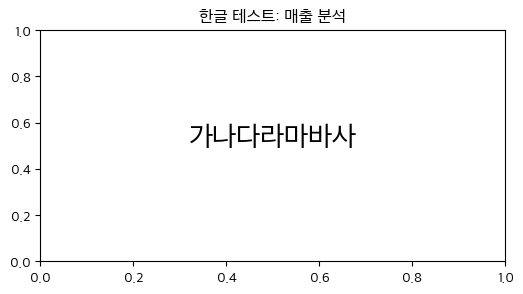

In [67]:
# ============================================================================
# 라이브러리 임포트 및 환경 설정
# ============================================================================

# Step 1: 핵심 라이브러리 임포트
import pandas as pd          # 데이터프레임 처리
import numpy as np           # 수치 연산
import matplotlib.pyplot as plt  # 기본 시각화
import seaborn as sns        # 고급 시각화
from datetime import datetime
import os
import warnings
warnings.filterwarnings('ignore')  # 경고 메시지 숨김

# Step 2: 한글 폰트 설정 (시각화에서 한글 깨짐 방지)
plt.rcParams['font.family'] = 'Apple SD Gothic Neo'  # Mac의 경우
# Windows: 'Malgun Gothic', Linux: 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# Step 3: 한글 출력 테스트
plt.figure(figsize=(6, 3))
plt.title('한글 테스트: 매출 분석')
plt.text(0.5, 0.5, '가나다라마바사', fontsize=20, ha='center')
plt.show()
#  한글이 정상적으로 표시되면 환경 설정 완료!

# 분석 결과 저장 경로
EXPORT_PATH = './results/part1/'
os.makedirs(EXPORT_PATH, exist_ok=True)

md_parts = []


In [68]:
# ============================================================================
# 데이터 로딩 - 5개의 CSV 파일 불러오기
# ============================================================================
#  비즈니스 맥락:
# - 에콰도르 대형 식료품 소매체인 Corporación Favorita의 데이터
# - 54개 매장, 33개 상품 카테고리, 4.5년치 일별 매출 데이터
# ============================================================================

# Step 1: 데이터 경로 설정
DATA_PATH = './data/'

# Step 2: 5개 CSV 파일 로딩
# - train: 핵심 매출 데이터 (매장 × 카테고리 × 날짜)
# - stores: 매장 정보 (위치, 타입, 클러스터)
# - oil: 유가 데이터 (에콰도르는 산유국  경제 영향)
# - holidays: 휴일/이벤트 데이터
# - transactions: 일별 거래건수

train = pd.read_csv(f'{DATA_PATH}train.csv', parse_dates=['date'])
stores = pd.read_csv(f'{DATA_PATH}stores.csv')
oil = pd.read_csv(f'{DATA_PATH}oil.csv', parse_dates=['date'])
holidays = pd.read_csv(f'{DATA_PATH}holidays_events.csv', parse_dates=['date'])
transactions = pd.read_csv(f'{DATA_PATH}transactions.csv', parse_dates=['date'])

# Step 3: 데이터 완결성 처리
#  2017년 8월은 15일까지만 데이터 존재  불완전한 월은 분석에서 제외
cutoff_date = '2017-07-31'
train = train[train['date'] <= cutoff_date]
oil = oil[oil['date'] <= cutoff_date]
holidays = holidays[holidays['date'] <= cutoff_date]
transactions = transactions[transactions['date'] <= cutoff_date]

#  참고: 2017년 8월 데이터 불완전으로 7월까지만 사용

### 데이터셋별 컬럼 정의

에콰도르의 대형 식료품 소매체인 **Corporación Favorita**의 매출 데이터입니다.

---

#### train.csv - 매출 데이터 (핵심 데이터)
| 컬럼 | 타입 | 설명 |
|------|------|------|
| id | int | 고유 식별자 |
| date | datetime | 판매 날짜 |
| store_nbr | int | 매장 번호 (1~54) |
| family | string | 상품 카테고리 (33개) |
| sales | float | 해당 카테고리의 일별 매출액 |
| onpromotion | int | 프로모션 중인 상품 수 |

---

#### stores.csv - 매장 정보
| 컬럼 | 타입 | 설명 |
|------|------|------|
| store_nbr | int | 매장 번호 |
| city | string | 도시명 (22개 도시) |
| state | string | 주/지역명 (16개 주) |
| type | string | 매장 타입 (A, B, C, D, E) - 규모/특성 구분 |
| cluster | int | 매장 클러스터 (1~17) - 유사 매장 그룹 |

---

#### holidays_events.csv - 휴일/이벤트 정보
| 컬럼 | 타입 | 설명 |
|------|------|------|
| date | datetime | 날짜 |
| type | string | 휴일/이벤트 유형 |
| locale | string | 적용 범위 (National/Regional/Local) |
| locale_name | string | 지역명 (National이면 'Ecuador', 아니면 도시/주 이름) |
| description | string | 휴일/이벤트 설명 |
| transferred | bool | 휴일 이전 여부 |

**type 상세 정의:**
| Type | 한국어 | 설명 | 매출 영향 예상 |
|------|--------|------|---------------|
| Holiday | 공휴일 | 법정 공휴일, 국경일, 지역 기념일 | ↓ 감소 (휴무) |
| Event | 이벤트 | 특별 행사, 축제 | ↑ 증가 |
| Transfer | 대체 휴일 | 원래 휴일이 다른 날로 이전 | - |
| Additional | 추가 휴일 | 연휴 기간 추가 지정일 (예: 크리스마스 전후) | ↑ 증가 (사전 구매) |
| Bridge | 징검다리 휴일 | 휴일과 주말 사이 연결 휴무일 (Puente) | ↑ 증가 |
| Work Day | 대체 근무일 | 징검다리 휴일 사용에 따른 보상 근무 (토요일) | ↑ 정상 영업 |

---

#### oil.csv - 유가 정보
| 컬럼 | 타입 | 설명 |
|------|------|------|
| date | datetime | 날짜 |
| dcoilwtico | float | WTI 원유 가격 (USD) - 에콰도르는 산유국으로 경제에 영향 |

---

#### transactions.csv - 거래 정보
| 컬럼 | 타입 | 설명 |
|------|------|------|
| date | datetime | 날짜 |
| store_nbr | int | 매장 번호 |
| transactions | int | 해당 매장의 일별 거래 건수 |

In [69]:
# ============================================================================
# 데이터 탐색 1단계: 각 데이터셋의 기본 정보 확인
# ============================================================================
# - 데이터 크기를 파악해야 분석 전략을 세울 수 있음
# - 데이터 타입이 맞지 않으면 연산 오류 발생
# - 결측치는 분석 전에 처리 방법 결정 필요
# ============================================================================

# 5개 데이터셋을 딕셔너리로 묶어서 반복문으로 처리
datasets = {
    'train': train,
    'stores': stores,
    'oil': oil,
    'holidays': holidays,
    'transactions': transactions
}

for name, df in datasets.items():
    # 데이터셋별 기본 정보 출력
    display(f"=== {name.upper()} ===")
    display(f"Shape: {df.shape}")
    display(df.head(2))

'=== TRAIN ==='

'Shape: (2974158, 6)'

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0


'=== STORES ==='

'Shape: (54, 5)'

...

'Shape: (323, 6)'

,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False


'=== TRANSACTIONS ==='

'Shape: (82678, 3)'

,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111


In [70]:
# Train 데이터 샘플 확인
# Train 데이터 샘플:
display(train.head(10))

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0
5,5,2013-01-01,1,BREAD/BAKERY,0.0,0
6,6,2013-01-01,1,CELEBRATION,0.0,0
7,7,2013-01-01,1,CLEANING,0.0,0
8,8,2013-01-01,1,DAIRY,0.0,0
9,9,2013-01-01,1,DELI,0.0,0


In [71]:
# Stores 데이터 확인
# Stores 데이터 전체:
display(stores)

,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4
5,6,Quito,Pichincha,D,13
6,7,Quito,Pichincha,D,8
7,8,Quito,Pichincha,D,8
8,9,Quito,Pichincha,B,6
9,10,Quito,Pichincha,C,15


In [72]:
# Holidays 데이터 확인
# Holidays 데이터 샘플:
display(holidays.head(10))


,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False
5,2012-05-12,Holiday,Local,Puyo,Cantonizacion del Puyo,False
6,2012-06-23,Holiday,Local,Guaranda,Cantonizacion de Guaranda,False
7,2012-06-25,Holiday,Regional,Imbabura,Provincializacion de Imbabura,False
8,2012-06-25,Holiday,Local,Latacunga,Cantonizacion de Latacunga,False
9,2012-06-25,Holiday,Local,Machala,Fundacion de Machala,False


In [73]:
# Oil 데이터 확인 (에콰도르는 원유 수출국)
# Oil 데이터 샘플:
display(oil.head())


,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20


In [74]:
# Transactions 데이터 확인
# Transactions 데이터 샘플:
display(transactions.head())


,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922


## 1.2 전체 매출 트렌드 시각화

시계열 트렌드 분석은 **"언제부터, 얼마나 변했는가"**를 파악하는 첫 단계입니다.

세 가지 시간 단위로 집계하여 서로 다른 패턴을 발견한다:
- **일별**: 단기 변동성, 이상치 탐지
- **월별**: 계절성 패턴 (연말 쇼핑 시즌 등)
- **연도별**: 장기 성장/둔화 트렌드, YoY 성장률

YoY(Year-over-Year) 성장률 = (올해 매출 - 작년 매출) / 작년 매출 × 100. 절대값이 아닌 비율로 비교해야 규모에 관계없이 성장세를 판단할 수 있습니다.


In [75]:
# ============================================================================
# 트렌드 분석을 위한 일별 매출 데이터 생성
# ============================================================================
#  비즈니스 질문:
# - "매출은 시간에 따라 어떻게 변화하는가?"
# - "성장하고 있는가, 둔화되고 있는가?"
# ============================================================================

# Step 1: 일별 총 매출 계산
# train 데이터는 매장×카테고리×날짜 단위  날짜별로 합산
daily_sales = train.groupby('date')['sales'].sum().reset_index()
daily_sales.columns = ['date', 'total_sales']

# Step 2: 시간 관련 파생 변수(Feature) 생성
# dt accessor를 사용하면 datetime에서 다양한 정보 추출 가능
daily_sales['year'] = daily_sales['date'].dt.year           # 연도 (2013~2017)
daily_sales['month'] = daily_sales['date'].dt.month         # 월 (1~12)
daily_sales['week'] = daily_sales['date'].dt.isocalendar().week  # 주차 (1~52)
daily_sales['weekday'] = daily_sales['date'].dt.weekday     # 요일 (0=월요일, 6=일요일)
daily_sales['year_month'] = daily_sales['date'].dt.to_period('M')  # 연-월 (2013-01 형식)

# Step 3: 결과 확인
display(daily_sales.head())

,date,total_sales,year,month,week,weekday,year_month
0,2013-01-01,2511.618999,2013,1,1,1,2013-01
1,2013-01-02,496092.417944,2013,1,1,2,2013-01
2,2013-01-03,361461.231124,2013,1,1,3,2013-01
3,2013-01-04,354459.677093,2013,1,1,4,2013-01
4,2013-01-05,477350.121229,2013,1,1,5,2013-01


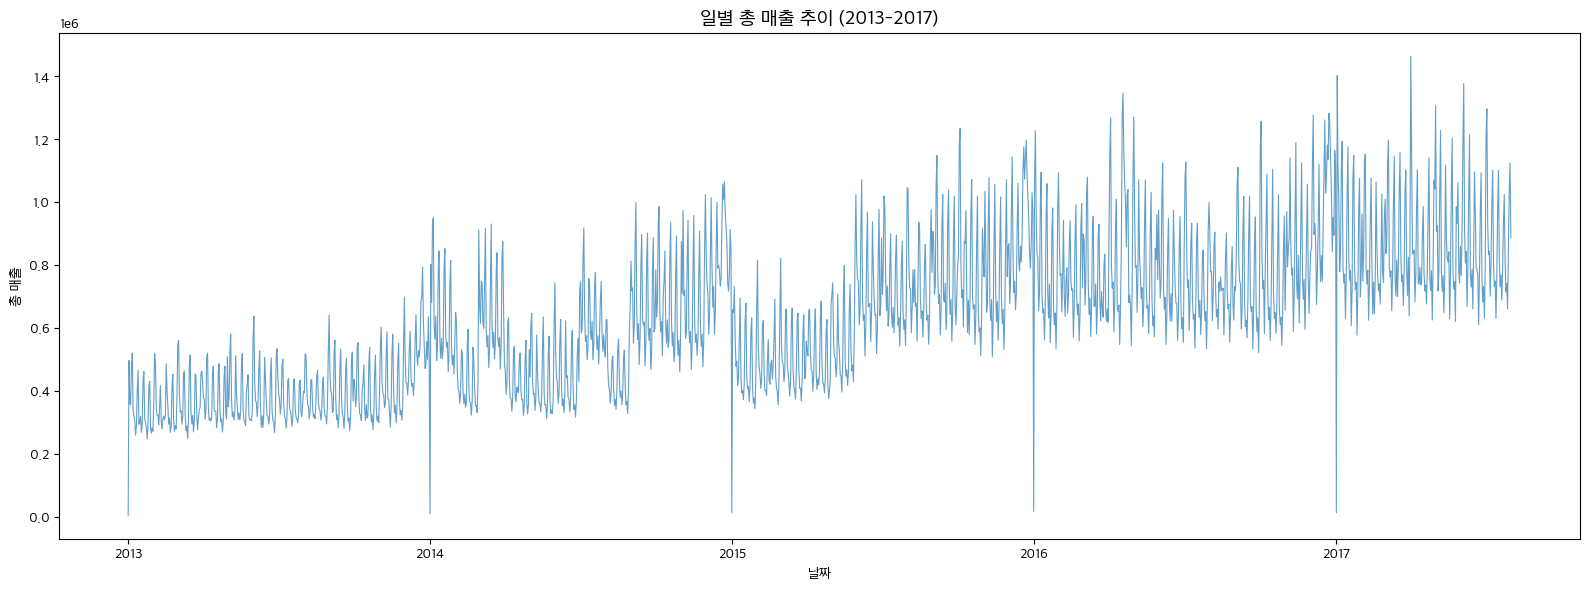

,date,total_sales
0,2013-01-01,2511.618999
364,2014-01-01,8602.065404
1457,2017-01-01,12082.500997
728,2015-01-01,12773.616980
1092,2016-01-01,16433.394000


In [76]:
# 전체 일별 매출 추이
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(daily_sales['date'], daily_sales['total_sales'], alpha=0.7, linewidth=0.8)
ax.set_title('일별 총 매출 추이 (2013-2017)', fontsize=14, fontweight='bold')
ax.set_xlabel('날짜')
ax.set_ylabel('총 매출')

plt.tight_layout()
plt.show()

# 매출 급락일 확인: 매출 최저 Top 5
lowest_days = daily_sales.nsmallest(5, 'total_sales')[['date', 'total_sales']]
display(lowest_days)

In [77]:
# ============================================================================
# 연도별 매출 및 YoY 성장률 분석
# ============================================================================
#  비즈니스 질문:
# - "매출이 매년 성장하고 있는가?"
# - "성장률이 둔화되고 있는가?"
#  YoY 계산 공식:
#    YoY 성장률 = (금년 매출 - 전년 매출) / 전년 매출 × 100%
# ============================================================================

# Step 1: 연도별 총 매출 집계
yearly_sales = daily_sales.groupby('year')['total_sales'].sum().reset_index()

# Step 2: YoY 계산을 위해 2017년 제외 (7월까지만 데이터 있어서 비교 불공정)
yearly_sales_for_yoy = yearly_sales[yearly_sales['year'] < 2017].copy()



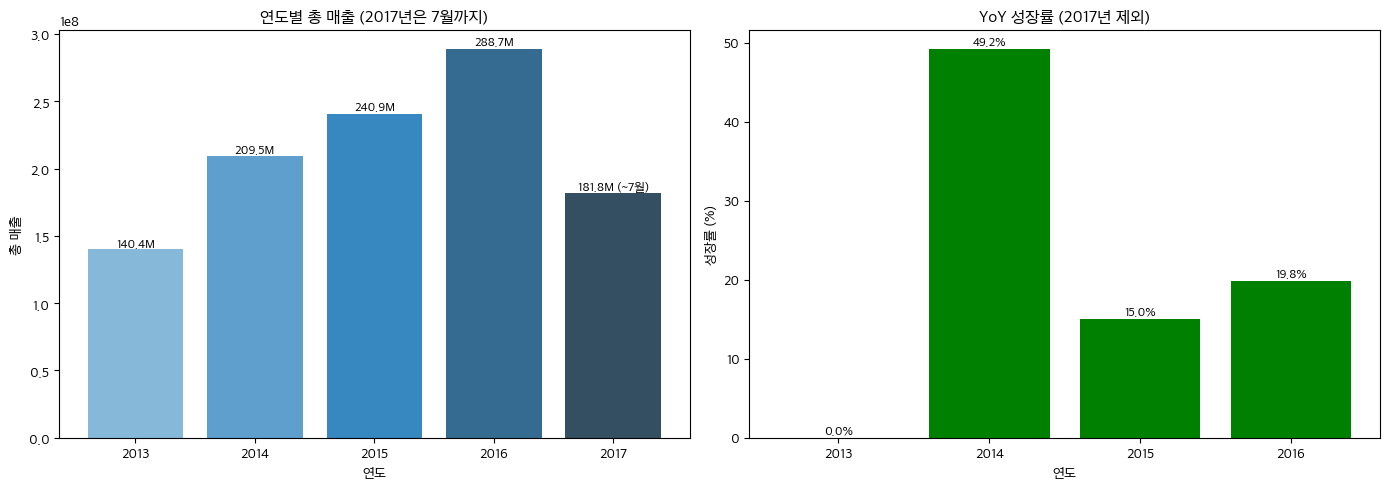

In [78]:
# Step 3: 시각화 (2개 차트: 매출 추이 + 성장률)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 차트 1: 연도별 총 매출 (절대값)
colors = sns.color_palette('Blues_d', n_colors=len(yearly_sales))
axes[0].bar(yearly_sales['year'], yearly_sales['total_sales'], color=colors)
axes[0].set_xticks(yearly_sales['year'])
axes[0].set_title('연도별 총 매출 (2017년은 7월까지)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('연도')
axes[0].set_ylabel('총 매출')

for i, v in enumerate(yearly_sales['total_sales']):
    label = f'{v/1e6:.1f}M'
    if yearly_sales['year'].iloc[i] == 2017:
        label += ' (~7월)'
    axes[0].text(yearly_sales['year'].iloc[i], v + v*0.01, label, ha='center', fontsize=9)

# 차트 2: YoY 성장률 (성장/둔화 패턴 확인)
# pct_change(): 이전 행 대비 변화율 계산  × 100으로 퍼센트 변환
yearly_sales_for_yoy['yoy_growth'] = yearly_sales_for_yoy['total_sales'].pct_change() * 100
colors_yoy = ['green' if x >= 0 else 'red' for x in yearly_sales_for_yoy['yoy_growth'].fillna(0)]
axes[1].bar(yearly_sales_for_yoy['year'], yearly_sales_for_yoy['yoy_growth'].fillna(0), color=colors_yoy)
axes[1].set_xticks(yearly_sales_for_yoy['year'])
axes[1].set_title('YoY 성장률 (2017년 제외)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('연도')
axes[1].set_ylabel('성장률 (%)')
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)

for i, v in enumerate(yearly_sales_for_yoy['yoy_growth'].fillna(0)):
    axes[1].text(yearly_sales_for_yoy['year'].iloc[i], v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()


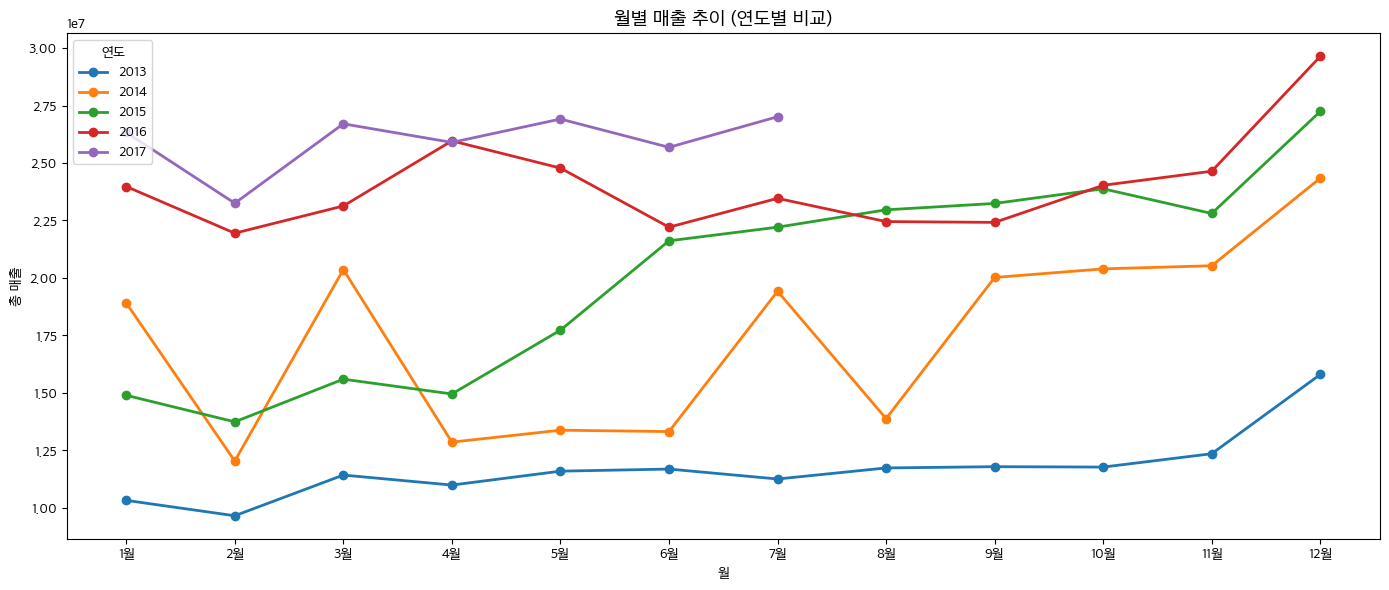

In [79]:
# 월별 매출 추이 (연도별 비교)
monthly_sales = daily_sales.groupby(['year', 'month'])['total_sales'].sum().reset_index()

fig, ax = plt.subplots(figsize=(14, 6))

for year in monthly_sales['year'].unique():
    year_data = monthly_sales[monthly_sales['year'] == year]
    ax.plot(year_data['month'], year_data['total_sales'], marker='o', label=str(year), linewidth=2)

ax.set_title('월별 매출 추이 (연도별 비교)', fontsize=14, fontweight='bold')
ax.set_xlabel('월')
ax.set_ylabel('총 매출')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['1월', '2월', '3월', '4월', '5월', '6월', '7월', '8월', '9월', '10월', '11월', '12월'])
ax.legend(title='연도', loc='upper left')

plt.tight_layout()
plt.show()

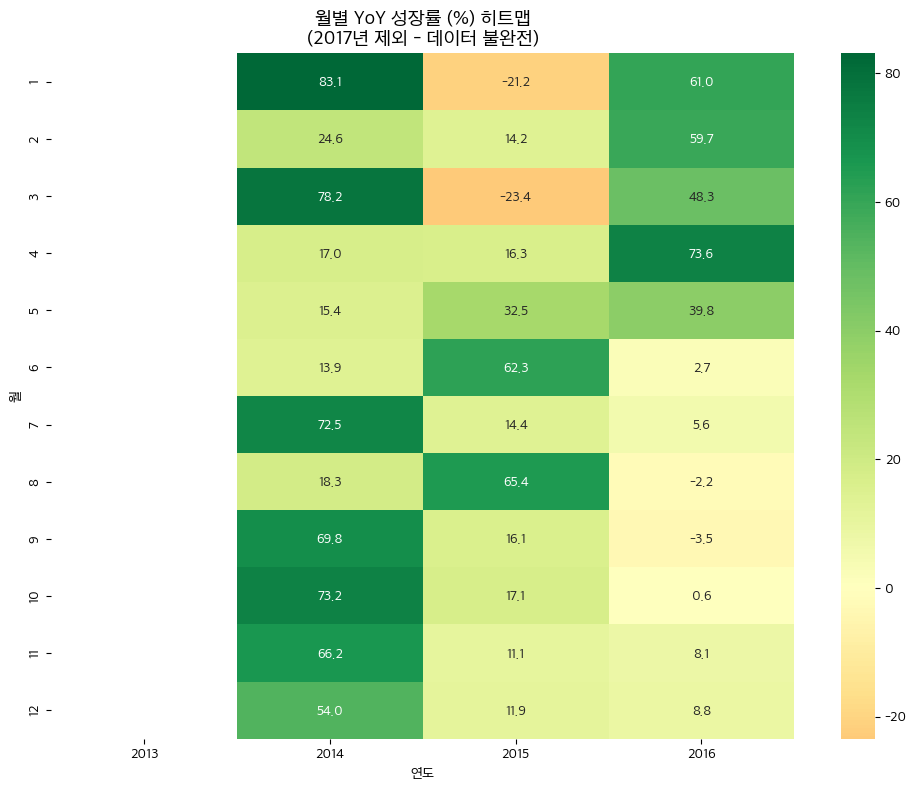

In [80]:
# 월별 YoY 성장률 히트맵
monthly_sales_for_yoy = monthly_sales[monthly_sales['year'] < 2017]
monthly_pivot = monthly_sales_for_yoy.pivot(index='month', columns='year', values='total_sales')

# YoY 성장률 계산
yoy_growth = monthly_pivot.pct_change(axis=1) * 100

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(yoy_growth, annot=True, fmt='.1f', cmap='RdYlGn', center=0, ax=ax)
ax.set_title('월별 YoY 성장률 (%) 히트맵\n(2017년 제외 - 데이터 불완전)', fontsize=14, fontweight='bold')
ax.set_xlabel('연도')
ax.set_ylabel('월')

plt.tight_layout()
plt.show()

In [81]:
# 1.2 분석 결과 CSV 저장
daily_sales.to_csv(f'{EXPORT_PATH}daily_sales.csv', index=False)
yearly_sales.to_csv(f'{EXPORT_PATH}yearly_sales.csv', index=False)
monthly_sales.to_csv(f'{EXPORT_PATH}monthly_sales.csv', index=False)
yoy_growth.to_csv(f'{EXPORT_PATH}yoy_growth.csv')

print(f"1.2 CSV 저장 완료: {EXPORT_PATH}")

1.2 CSV 저장 완료: ./results/part1/


## 1.1~1.2 분석 결과 · 시각화 인사이트 요약

### 1. 연도별/월별 매출 트렌드
- 2013~2016: 연간 매출이 꾸준히 성장 (2017년 데이터는 불충분)
- 연말(12월) 매출이 월중 최대, 2월이 최저 → **뚜렷한 계절성 패턴**
- 연도별 성장률(YoY)은 매년 점진적으로 둔화

### 2. YoY 성장률 (월별 히트맵 시각화)
- 일부 연∙월 구간에서 급격한 성장/둔화 패턴 관찰

### 3. 종합 인사이트
- 매출의 지속적 성장과 강한 계절성(12월 피크, 2월 최저), 그리고 성장률 둔화 흐름이 확인됨

In [82]:
md_parts.append("""## 1.1~1.2 분석 결과 · 시각화 인사이트 요약

### 1. 연도별/월별 매출 트렌드
- 2013~2016: 연간 매출이 꾸준히 성장 (2017년 데이터는 불충분)
- 연말(12월) 매출이 월중 최대, 2월이 최저 → **뚜렷한 계절성 패턴**
- 연도별 성장률(YoY)은 매년 점진적으로 둔화

### 2. YoY 성장률 (월별 히트맵 시각화)
- 일부 연∙월 구간에서 급격한 성장/둔화 패턴 관찰

### 3. 종합 인사이트
- 매출의 지속적 성장과 강한 계절성(12월 피크, 2월 최저), 그리고 성장률 둔화 흐름이 확인됨
""")
print(f"md_parts 누적 완료 ({len(md_parts)}개)")

md_parts 누적 완료 (1개)


## 1.3 매출 영향 요인 분석

매출에 영향을 미치는 다양한 요인(프로모션, 요일, 계절성, 휴일, 유가 등)을 분석합니다.

In [83]:
# Train 데이터에 매장 정보 병합 (세그먼트 분석용)
train_merged = train.merge(stores, on='store_nbr', how='left')

### 1.3.1 프로모션 효과 분석

프로모션 효과를 측정하는 기본 지표는 **리프트(Lift)**다:

```
리프트(%) = (프로모션 매출 - 비프로모션 매출) / 비프로모션 매출 × 100
```

리프트가 50%라면 프로모션 시 매출이 50% 더 높았다는 의미입니다. 단, 이는 상관관계이지 인과관계가 아닐 수 있습니다 — 원래 잘 팔리는 상품에 프로모션을 거는 경향이 있기 때문입니다. 카테고리별로 리프트를 비교하면 프로모션 효율이 높은 카테고리를 식별할 수 있습니다.

> 참고: [Confounding Variables in A/B Testing (Statsig)](https://www.statsig.com/perspectives/confounding-variables-ab-testing-solutions)


In [84]:
# ============================================================================
# 프로모션 효과 분석 - A/B 테스트 관점
# ============================================================================
#  비즈니스 질문:
# - "프로모션이 매출에 얼마나 효과가 있는가?"
# - "어떤 카테고리에서 프로모션 효과가 큰가?"
#  리프트 계산 공식:
#    Lift = (프로모션 매출 - 일반 매출) / 일반 매출 × 100%
# ============================================================================

# Step 1: 프로모션 여부 플래그 생성 (0: 없음, 1: 있음)
train['has_promo'] = (train['onpromotion'].fillna(0) > 0).astype(int)
train['year'] = train['date'].dt.year

# Step 2: 전체 프로모션 효과 계산
no_promo_avg = train[train['has_promo'] == 0]['sales'].mean()  # 프로모션 없을 때 평균
promo_avg = train[train['has_promo'] == 1]['sales'].mean()     # 프로모션 있을 때 평균
lift = ((promo_avg - no_promo_avg) / no_promo_avg) * 100       # 리프트 계산



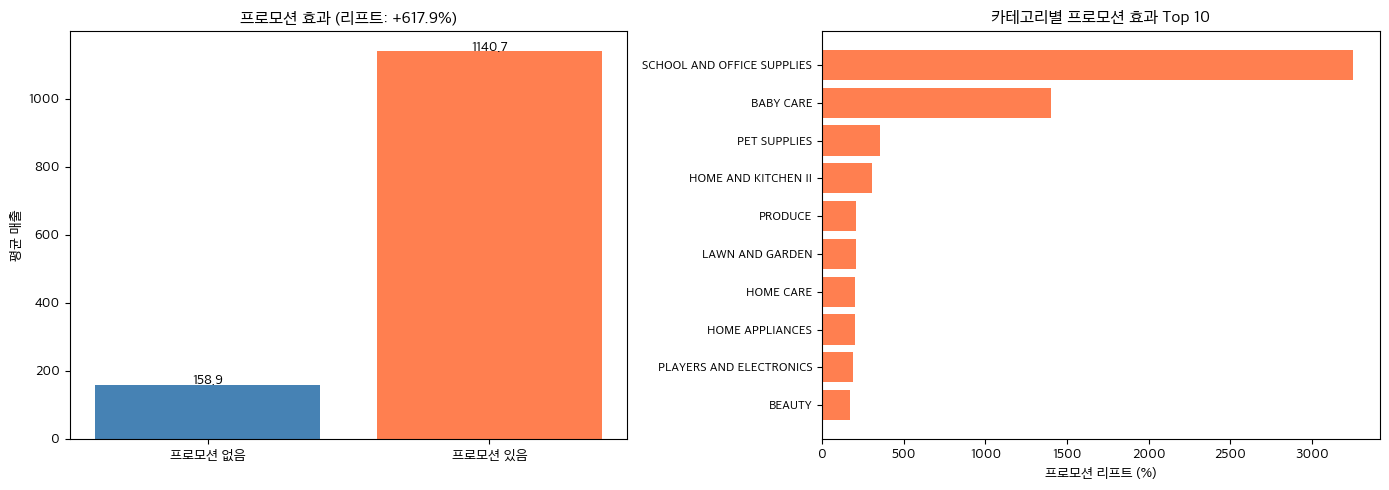

In [85]:
# Step 3: 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 차트 1: 프로모션 여부별 평균 매출 비교
bars = axes[0].bar(['프로모션 없음', '프로모션 있음'], [no_promo_avg, promo_avg], 
                   color=['steelblue', 'coral'])
axes[0].set_title(f'프로모션 효과 (리프트: +{lift:.1f}%)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('평균 매출')

for bar, val in zip(bars, [no_promo_avg, promo_avg]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                f'{val:.1f}', ha='center', fontsize=10)

# 차트 2: 카테고리별 프로모션 효과 Top 10
# groupby + unstack으로 피벗 테이블 생성
promo_by_cat = train.groupby(['family', 'has_promo'])['sales'].mean().unstack()
promo_by_cat['lift'] = ((promo_by_cat[1] - promo_by_cat[0]) / promo_by_cat[0]) * 100
top_lift = promo_by_cat.nlargest(10, 'lift')

axes[1].barh(range(len(top_lift)), top_lift['lift'], color='coral')
axes[1].set_yticks(range(len(top_lift)))
axes[1].set_yticklabels(top_lift.index, fontsize=9)
axes[1].set_xlabel('프로모션 리프트 (%)')
axes[1].set_title('카테고리별 프로모션 효과 Top 10', fontsize=12, fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# 로모션은 매출 증가에 효과적, 특히 특정 카테고리에서 더 효과적

In [86]:
promo_by_cat

has_promo,0,1,lift
family,,,
AUTOMOTIVE,5.838817,13.251888,126.961882
BABY CARE,0.109055,1.634615,1398.893883
BEAUTY,3.080061,8.245760,167.714130
BEVERAGES,1291.947716,3211.600809,148.585974
BOOKS,0.071345,NaN,NaN
BREAD/BAKERY,379.138384,576.487914,52.052110
CELEBRATION,7.901657,19.982221,152.886472
CLEANING,868.323130,1240.819017,42.898303
DAIRY,479.747286,935.178339,94.931450


has_promo,0,1,lift
family,,,
PRODUCE,791.905740,2442.375857,208.417496
BEVERAGES,1291.947716,3211.600809,148.585974
DAIRY,479.747286,935.178339,94.931450
GROCERY I,2717.410729,4408.653061,62.237273
POULTRY,312.790706,486.489937,55.532095
MEATS,302.723379,466.738770,54.179955
PERSONAL CARE,220.867557,339.165295,53.560486
BREAD/BAKERY,379.138384,576.487914,52.052110
DELI,221.759384,322.059644,45.229320


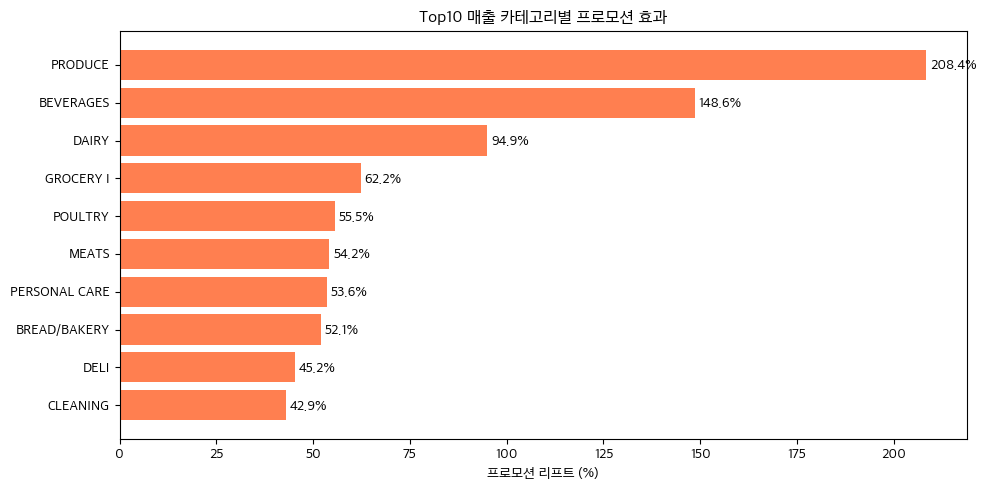

In [87]:
# 판매 매출이 높은 제품 top10을 기준으로 lift 효과와 시각화

# 1. 카테고리별 총 매출 합계 계산 (top10)
top10_families = train.groupby('family')['sales'].sum().nlargest(10).index

# 2. 이 top10 카테고리 내에서 프로모션 lift 효과 계산
promo_top10 = promo_by_cat.loc[top10_families].copy()
promo_top10 = promo_top10.sort_values('lift', ascending=False)

# 3. 테이블 출력
display(promo_top10)

# 4. 시각화: Top10 매출 카테고리별 프로모션 lift 효과
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
bars = ax.barh(promo_top10.index, promo_top10['lift'], color='coral')
ax.set_xlabel('프로모션 리프트 (%)')
ax.set_title('Top10 매출 카테고리별 프로모션 효과', fontsize=12, fontweight='bold')
ax.invert_yaxis()

# 값 표시
for bar in bars:
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
            f'{bar.get_width():.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.show()

### 1.3.2 요일별 패턴 분석

요일별 소비 패턴은 유통업에서 **인력 배치, 재고 관리, 프로모션 타이밍**에 직접 영향을 줍니다. 일반적으로 주말에 매출이 높지만, 에콰도르에서는 일요일에 매장이 쉬는 경우가 있어 패턴이 다를 수 있습니다. 요일별 평균 매출을 비교하여 최적의 프로모션 요일을 결정합니다.


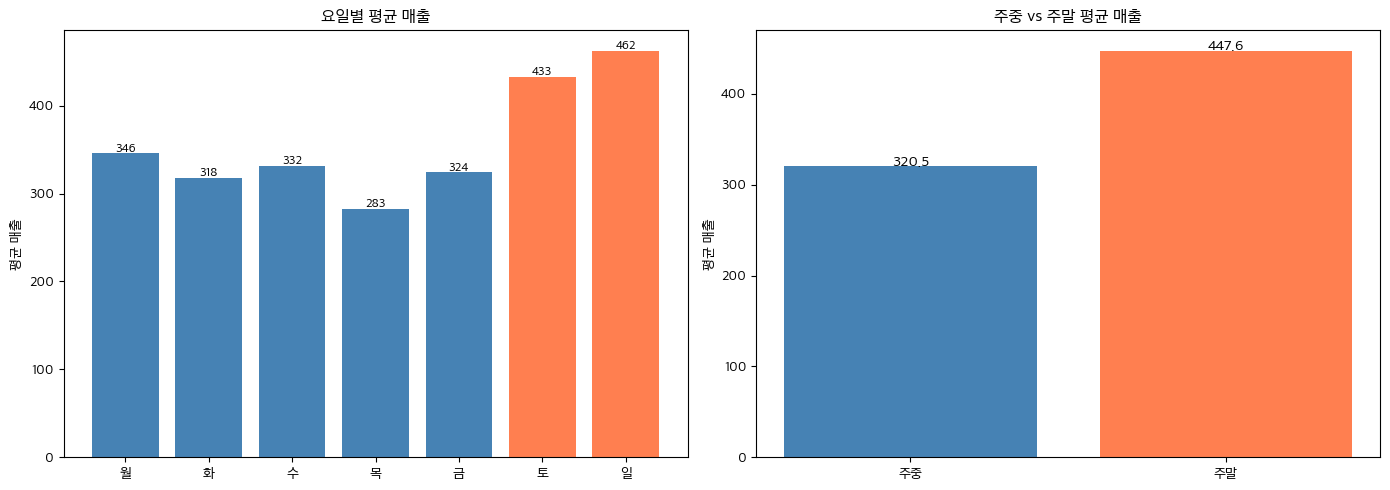

In [88]:
# 요일별 패턴 분석
train['dayofweek'] = train['date'].dt.dayofweek
train['day_name'] = train['date'].dt.day_name()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. 요일별 평균 매출
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_sales = train.groupby('day_name')['sales'].mean().reindex(day_order)

colors = ['steelblue'] * 5 + ['coral'] * 2  # 주중 파랑, 주말 빨강
bars = axes[0].bar(range(7), day_sales.values, color=colors)
axes[0].set_xticks(range(7))
axes[0].set_xticklabels(['월', '화', '수', '목', '금', '토', '일'])
axes[0].set_title('요일별 평균 매출', fontsize=12, fontweight='bold')
axes[0].set_ylabel('평균 매출')

for bar, val in zip(bars, day_sales.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, 
                f'{val:.0f}', ha='center', fontsize=9)

# 2. 주중 vs 주말 비교
train['is_weekend'] = train['dayofweek'].isin([5, 6]).astype(int)
weekend_compare = train.groupby('is_weekend')['sales'].mean()
weekend_compare.index = ['주중', '주말']

axes[1].bar(weekend_compare.index, weekend_compare.values, color=['steelblue', 'coral'])
axes[1].set_title('주중 vs 주말 평균 매출', fontsize=12, fontweight='bold')
axes[1].set_ylabel('평균 매출')

for i, val in enumerate(weekend_compare.values):
    axes[1].text(i, val + 0.3, f'{val:.1f}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

In [89]:
# 1.3.1~2 분석 결과 CSV 저장
promo_effect = train.groupby('has_promo')['sales'].agg(['mean', 'count']).reset_index()
promo_effect.columns = ['has_promo', 'avg_sales', 'count']
promo_effect.to_csv(f'{EXPORT_PATH}promo_effect.csv', index=False)

category_sales = train.groupby('family')['sales'].agg(['sum', 'mean']).reset_index()
category_sales.columns = ['family', 'total_sales', 'avg_sales']
category_sales = category_sales.sort_values('total_sales', ascending=False)
category_sales.to_csv(f'{EXPORT_PATH}category_sales.csv', index=False)

promo_by_cat_export = promo_by_cat.reset_index()
promo_by_cat_export.columns = ['family', 'no_promo_avg', 'promo_avg', 'lift_pct']
promo_by_cat_export.to_csv(f'{EXPORT_PATH}promo_by_category.csv', index=False)

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_sales_export = train.groupby('day_name')['sales'].mean().reindex(day_order)
weekday_df = pd.DataFrame({
    'day_name': day_order,
    'day_korean': ['월', '화', '수', '목', '금', '토', '일'],
    'avg_sales': day_sales_export.values,
    'is_weekend': [False, False, False, False, False, True, True]
})
weekday_df.to_csv(f'{EXPORT_PATH}weekday_pattern.csv', index=False)

print(f"1.3.1~2 CSV 저장 완료: {EXPORT_PATH}")

1.3.1~2 CSV 저장 완료: ./results/part1/


## 1.3.1~1.3.2 프로모션 효과 및 요일별 패턴

### 1. 프로모션 리프트
- 프로모션일 평균 매출이 비프로모션일 대비 리프트(%)로 **양(+) 효과**가 나타남
- 단기 매출 신장에는 유리하나, 리프트는 **상관**에 가깝고 **인과**로 단정하기 어려움 (고매출 품목·시점에 프로모션이 몰리는 편향 가능)

### 2. 카테고리·요일 패턴
- **GROCERY I, BEVERAGES, PRODUCE** 등 주요 카테고리는 프로모션 효과(리프트)가 크고, 일부 카테고리는 상대적으로 작음
- 프로모션 효과는 **연도·월·요일·카테고리**에 따라 달라져 **세분 타깃** 전략이 필요함
- **주말(토·일)·금요일**에 평균 매출 상승 경향 → 인력·재고·프로모션을 요일별로 계획할 가치가 있음
- 연초·연말·휴일 등에는 주중·주말 매출 격차가 더 벌어지는 구간이 있음 (휴일·이벤트 분석과 연계)

### 3. 종합 인사이트
- 카테고리·요일·시점을 나눈 프로모션 설계와 **빈도·배분 정책** 검토가 필요함
- 특수일·이벤트 기간 성과는 **추가 분석**(예: 1.3.4 휴일 효과)과 함께 보는 것이 타당함

In [92]:
md_parts.append("""
## 1.3.1~1.3.2 프로모션 효과 및 요일별 패턴

### 1. 프로모션 리프트
- 프로모션일 평균 매출이 비프로모션일 대비 리프트(%)로 **양(+) 효과**가 나타남
- 단기 매출 신장에는 유리하나, 리프트는 **상관**에 가깝고 **인과**로 단정하기 어려움 (고매출 품목·시점에 프로모션이 몰리는 편향 가능)

### 2. 카테고리·요일 패턴
- **GROCERY I, BEVERAGES, PRODUCE** 등 주요 카테고리는 프로모션 효과(리프트)가 크고, 일부 카테고리는 상대적으로 작음
- 프로모션 효과는 **연도·월·요일·카테고리**에 따라 달라져 **세분 타깃** 전략이 필요함
- **주말(토·일)·금요일**에 평균 매출 상승 경향 → 인력·재고·프로모션을 요일별로 계획할 가치가 있음
- 연초·연말·휴일 등에는 주중·주말 매출 격차가 더 벌어지는 구간이 있음 (휴일·이벤트 분석과 연계)

### 3. 종합 인사이트
- 카테고리·요일·시점을 나눈 프로모션 설계와 **빈도·배분 정책** 검토가 필요함
- 특수일·이벤트 기간 성과는 **추가 분석**(예: 1.3.4 휴일 효과)과 함께 보는 것이 타당함
""")
print(f"md_parts 누적 완료 ({len(md_parts)}개)")

md_parts 누적 완료 (3개)


### 1.3.3 계절성 수요 패턴 분석

**계절성(Seasonality)**이란 일정한 주기로 반복되는 매출 패턴입니다. 월별 평균 매출을 계산하면 연중 어느 시점에 매출이 높고 낮은지 파악할 수 있습니다.

**계절지수(Seasonal Index)** = 해당 월 평균 매출 / 전체 월 평균 매출. 계절지수가 1.2이면 연평균보다 20% 높다는 뜻입니다. 이를 통해 재고 계획과 프로모션 캘린더를 수립합니다.


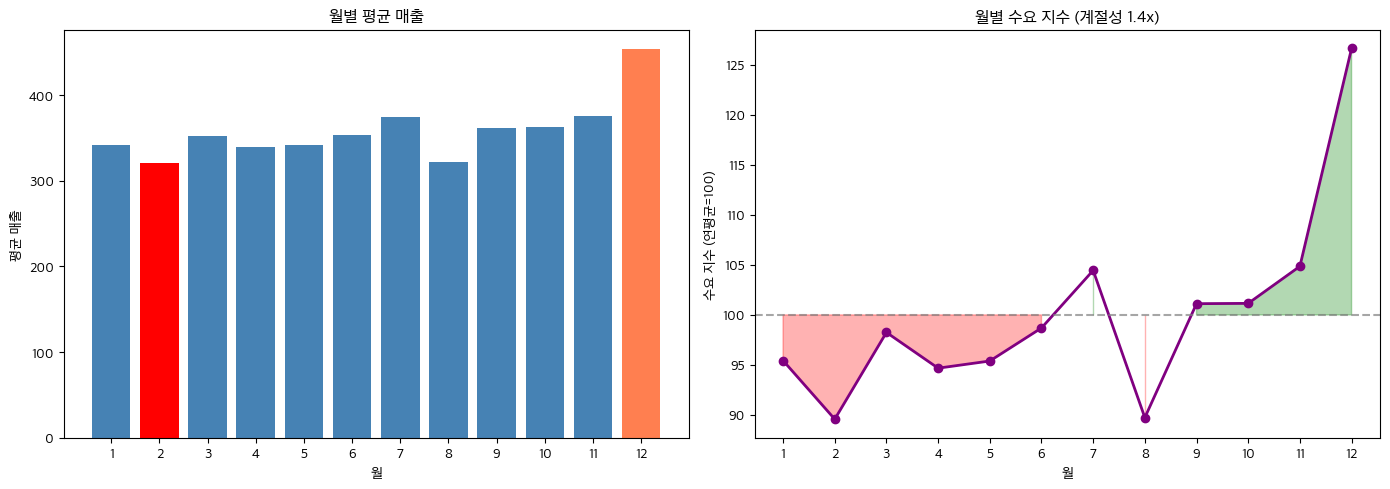

In [93]:
# 계절성 수요 패턴 분석
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. 월별 평균 매출
monthly_avg = train.groupby(train['date'].dt.month)['sales'].mean()
colors = ['coral' if m == 12 else 'red' if m == 2 else 'steelblue' for m in monthly_avg.index]
axes[0].bar(monthly_avg.index, monthly_avg.values, color=colors)
axes[0].set_title('월별 평균 매출', fontsize=12, fontweight='bold')
axes[0].set_xlabel('월')
axes[0].set_ylabel('평균 매출')
axes[0].set_xticks(range(1, 13))

# 계절성 비율
peak = monthly_avg.max()  # 12월
low = monthly_avg.min()   # 2월
ratio = peak / low

# 2. 월별 수요 지수
monthly_index = (monthly_avg / monthly_avg.mean() * 100)
axes[1].plot(monthly_index.index, monthly_index.values, marker='o', linewidth=2, color='purple')
axes[1].axhline(y=100, color='gray', linestyle='--', alpha=0.7)
axes[1].fill_between(monthly_index.index, 100, monthly_index.values, 
                     where=(monthly_index.values > 100), alpha=0.3, color='green')
axes[1].fill_between(monthly_index.index, 100, monthly_index.values, 
                     where=(monthly_index.values < 100), alpha=0.3, color='red')
axes[1].set_title(f'월별 수요 지수 (계절성 {ratio:.1f}x)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('월')
axes[1].set_ylabel('수요 지수 (연평균=100)')
axes[1].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()

## 1.3.3 계절성 수요 패턴

### 1. 월별 매출 사이클
- 겨울(특히 **12월**)에 매출이 크게 오르고, **2월** 등 연초에는 상대적으로 낮은 **계절적 사이클**이 매년 반복됨
- **12월**은 연중 피크에 가깝고, 연말·연휴·프로모션 등이 겹친 수요로 해석할 수 있음
- **1~2월**은 구매 수요가 둔화되는 **비수기** 경향이 관측됨

### 2. 계절지수(Seasonal Index)
- 월 평균 매출 ÷ 전체 월 평균으로 **연평균 대비 수준**을 정량화함
- 지수 **1.2** → 연평균 대비 약 20% 높은 달, **0.7** → 약 30% 낮은 달(예시)

### 3. 종합 인사이트
- 성수기(예: 12월)는 **재고·공급** 확보, 비수기(예: 1~2월)는 **과잉 재고·이월** 관리와 맞물려야 함
- 프로모션·마케팅 **일정**을 월별 계절지수와 함께 두는 것이 유리함

In [94]:
md_parts.append("""
## 1.3.3 계절성 수요 패턴

### 1. 월별 매출 사이클
- 겨울(특히 **12월**)에 매출이 크게 오르고, **2월** 등 연초에는 상대적으로 낮은 **계절적 사이클**이 매년 반복됨
- **12월**은 연중 피크에 가깝고, 연말·연휴·프로모션 등이 겹친 수요로 해석할 수 있음
- **1~2월**은 구매 수요가 둔화되는 **비수기** 경향이 관측됨

### 2. 계절지수(Seasonal Index)
- 월 평균 매출 ÷ 전체 월 평균으로 **연평균 대비 수준**을 정량화함
- 지수 **1.2** → 연평균 대비 약 20% 높은 달, **0.7** → 약 30% 낮은 달(예시)

### 3. 종합 인사이트
- 성수기(예: 12월)는 **재고·공급** 확보, 비수기(예: 1~2월)는 **과잉 재고·이월** 관리와 맞물려야 함
- 프로모션·마케팅 **일정**을 월별 계절지수와 함께 두는 것이 유리함
""")
print(f"md_parts 누적 완료 ({len(md_parts)}개)")

md_parts 누적 완료 (4개)


### 1.3.4 휴일/이벤트 효과 분석 (매장-지역 수준)

> holidays_events.csv와 stores.csv를 연계하여 **각 매장에 적용되는 휴일**이 **해당 매장 매출**에 미치는 영향을 분석합니다.

**휴일 적용 범위 및 매칭 로직:**
| Locale | 매칭 조건 | 적용 대상 |
|--------|----------|----------|
| **National** | 모든 매장 | 전국 54개 매장 |
| **Regional** | locale_name == 매장의 state | 해당 주 소재 매장만 |
| **Local** | locale_name == 매장의 city | 해당 도시 소재 매장만 |

**분석 목표:**
1. 매장별로 적용되는 휴일 플래그 생성
2. 휴일 적용 범위별 매출 영향 비교 (National vs Regional vs Local)
3. 해당 지역 매장 vs 비해당 지역 매장 매출 차이 분석
4. 휴일 유형(type)별 지역 효과 분석

In [145]:
# ============================================================================
# Step 1: 매장별 휴일 플래그 생성
# ============================================================================

# 매장별 일별 매출 데이터 생성 (매장-날짜 수준)
store_daily_sales = train.groupby(['date', 'store_nbr'])['sales'].sum().reset_index()
store_daily_sales = store_daily_sales.merge(stores[['store_nbr', 'city', 'state']], on='store_nbr', how='left')


# 휴일 데이터 분리
national_holidays = holidays[holidays['locale'] == 'National'][['date', 'type', 'description']].drop_duplicates('date')
regional_holidays = holidays[holidays['locale'] == 'Regional'][['date', 'type', 'locale_name', 'description']].drop_duplicates(['date', 'locale_name'])
local_holidays = holidays[holidays['locale'] == 'Local'][['date', 'type', 'locale_name', 'description']].drop_duplicates(['date', 'locale_name'])


# National 휴일 플래그 (모든 매장에 적용)
store_daily_sales = store_daily_sales.merge(
    national_holidays.rename(columns={'type': 'national_type', 'description': 'national_desc'}),
    on='date', how='left'
)
store_daily_sales['is_national_holiday'] = store_daily_sales['national_type'].notna()



In [146]:
# Regional 휴일 플래그 (해당 state 매장에만 적용)
store_daily_sales = store_daily_sales.merge(
    regional_holidays.rename(columns={'type': 'regional_type', 'locale_name': 'regional_state', 'description': 'regional_desc'}),
    left_on=['date', 'state'], right_on=['date', 'regional_state'], how='left'
)
store_daily_sales['is_regional_holiday'] = store_daily_sales['regional_type'].notna()

# Local 휴일 플래그 (해당 city 매장에만 적용)
store_daily_sales = store_daily_sales.merge(
    local_holidays.rename(columns={'type': 'local_type', 'locale_name': 'local_city', 'description': 'local_desc'}),
    left_on=['date', 'city'], right_on=['date', 'local_city'], how='left'
)
store_daily_sales['is_local_holiday'] = store_daily_sales['local_type'].notna()

# 휴일 유형 통합 (우선순위: Local > Regional > National)
def get_holiday_info(row):
    if row['is_local_holiday']:
        return 'Local', row['local_type']
    elif row['is_regional_holiday']:
        return 'Regional', row['regional_type']
    elif row['is_national_holiday']:
        return 'National', row['national_type']
    else:
        return None, None

store_daily_sales['holiday_locale'], store_daily_sales['holiday_type'] = zip(*store_daily_sales.apply(get_holiday_info, axis=1))
store_daily_sales['is_any_holiday'] = store_daily_sales['holiday_locale'].notna()


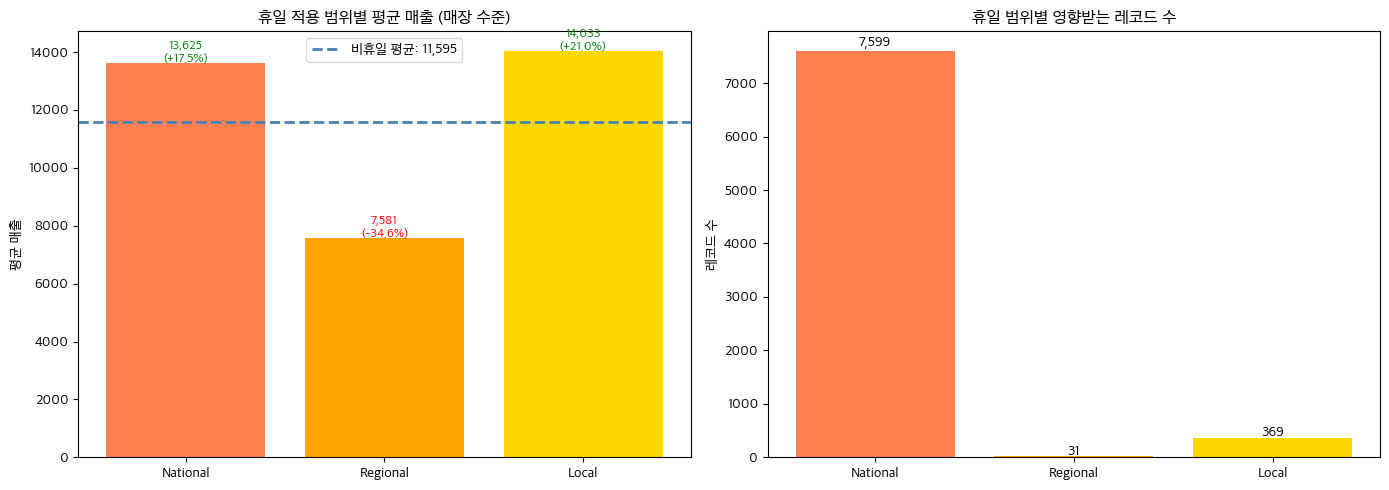

,locale,avg_sales,count,lift_pct
0,National,13625.145062,7599,17.509014
1,Regional,7580.939580,31,-34.618770
2,Local,14033.428273,369,21.030221


In [147]:
# ============================================================================
# Step 2: 휴일 적용 범위별 매출 영향 분석 (National vs Regional vs Local)
# ============================================================================

# 비휴일 평균 매출 (기준선)
non_holiday_avg = store_daily_sales[~store_daily_sales['is_any_holiday']]['sales'].mean()

# 휴일 적용 범위별 평균 매출
locale_sales = store_daily_sales[store_daily_sales['is_any_holiday']].groupby('holiday_locale')['sales'].agg(['mean', 'count']).reset_index()
locale_sales.columns = ['locale', 'avg_sales', 'count']
locale_sales['lift_pct'] = (locale_sales['avg_sales'] - non_holiday_avg) / non_holiday_avg * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. 휴일 범위별 평균 매출 비교
locale_order = ['National', 'Regional', 'Local']
locale_sales_sorted = locale_sales.set_index('locale').reindex(locale_order).reset_index()

colors = ['coral', 'orange', 'gold']
bars = axes[0].bar(locale_sales_sorted['locale'], locale_sales_sorted['avg_sales'], color=colors)
axes[0].axhline(y=non_holiday_avg, color='steelblue', linestyle='--', linewidth=2, label=f'비휴일 평균: {non_holiday_avg:,.0f}')
axes[0].set_title('휴일 적용 범위별 평균 매출 (매장 수준)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('평균 매출')
axes[0].legend()

for bar, row in zip(bars, locale_sales_sorted.itertuples()):
    lift = row.lift_pct
    color = 'red' if lift < 0 else 'green'
    label_text = f"{row.avg_sales:,.0f}\n({lift:+.1f}%)"
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
                label_text, ha='center', fontsize=9, color=color)

# 2. 휴일 범위별 레코드 수
axes[1].bar(locale_sales_sorted['locale'], locale_sales_sorted['count'], color=colors)
axes[1].set_title('휴일 범위별 영향받는 레코드 수', fontsize=12, fontweight='bold')
axes[1].set_ylabel('레코드 수')

for i, row in enumerate(locale_sales_sorted.itertuples()):
    axes[1].text(i, row.count + row.count*0.01, f'{row.count:,}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# 휴일 범위별 매출 영향 요약
display(locale_sales_sorted)

In [148]:
# ============================================================================
# Step 2-1: 휴일 매출 증가 원인 검증 (프로모션 vs 휴일 자체)
# ============================================================================
# 교란 변수(Confounding) 검증: 휴일에 매출이 높은 이유가 프로모션 때문인지?

# 매장-날짜-카테고리 수준에서 휴일 플래그 연결
train_with_holiday = train.merge(
    store_daily_sales[['date', 'store_nbr', 'is_any_holiday', 'holiday_locale']].drop_duplicates(), 
    on=['date', 'store_nbr'], 
    how='left'
)
train_with_holiday['is_any_holiday'] = train_with_holiday['is_any_holiday'].fillna(False)

# 1. 휴일/비휴일별 평균 프로모션 수 비교
promo_comparison = train_with_holiday.groupby('is_any_holiday').agg({
    'onpromotion': 'mean',
    'sales': 'mean'
}).round(2)
promo_comparison.index = ['비휴일', '휴일']
promo_comparison.columns = ['평균 프로모션 수', '평균 매출']



In [150]:
promo_comparison

,평균 프로모션 수,평균 매출
비휴일,2.50,351.36
휴일,3.32,412.74


In [ ]:
# 2. 프로모션=0인 날만 비교 (프로모션 효과 제거)
no_promo_data = train_with_holiday[train_with_holiday['onpromotion'] == 0]
no_promo_comparison = no_promo_data.groupby('is_any_holiday')['sales'].mean()
no_promo_comparison.index = ['비휴일', '휴일']

holiday_lift_no_promo = round(((no_promo_comparison['휴일'] - no_promo_comparison['비휴일']) / no_promo_comparison['비휴일']) * 100, 2)

In [154]:
holiday_lift_no_promo

np.float64(-6.17)

In [ ]:
# 3. 휴일 유형별 프로모션 비교
locale_promo = train_with_holiday.groupby('holiday_locale').agg({
    'onpromotion': 'mean',
    'sales': 'mean'
}).round(2)
locale_promo = locale_promo.rename(index={None: '비휴일'})
locale_promo.columns = ['평균 프로모션 수', '평균 매출']

,평균 프로모션 수,평균 매출
holiday_locale,,
Local,2.91,425.26
National,3.34,412.88
Regional,2.56,229.73


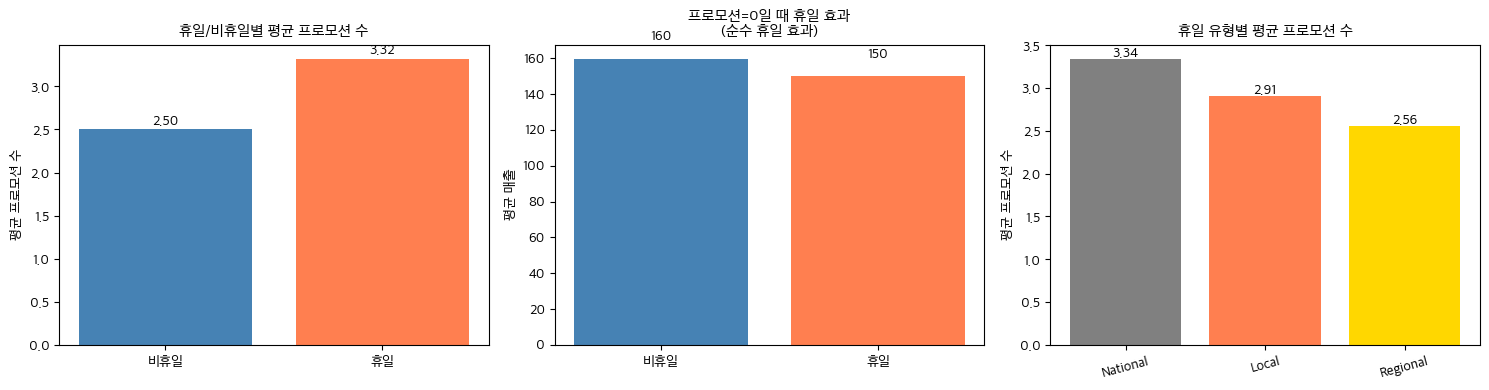

In [97]:
# 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. 휴일/비휴일 프로모션 비교
colors = ['steelblue', 'coral']
bars = axes[0].bar(promo_comparison.index, promo_comparison['평균 프로모션 수'], color=colors)
axes[0].set_title('휴일/비휴일별 평균 프로모션 수', fontsize=11, fontweight='bold')
axes[0].set_ylabel('평균 프로모션 수')
for bar, val in zip(bars, promo_comparison['평균 프로모션 수']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, f'{val:.2f}', ha='center')

# 2. 프로모션 제외 후 순수 휴일 효과
bars = axes[1].bar(no_promo_comparison.index, no_promo_comparison.values, color=colors)
axes[1].set_title('프로모션=0일 때 휴일 효과\n(순수 휴일 효과)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('평균 매출')
for bar, val in zip(bars, no_promo_comparison.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, f'{val:,.0f}', ha='center')

# 3. 휴일 유형별 프로모션 수
locale_promo_sorted = locale_promo.sort_values('평균 프로모션 수', ascending=False)
colors_locale = ['gray', 'coral', 'gold', 'teal']
bars = axes[2].bar(locale_promo_sorted.index, locale_promo_sorted['평균 프로모션 수'], color=colors_locale[:len(locale_promo_sorted)])
axes[2].set_title('휴일 유형별 평균 프로모션 수', fontsize=11, fontweight='bold')
axes[2].set_ylabel('평균 프로모션 수')
axes[2].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, locale_promo_sorted['평균 프로모션 수']):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.2f}', ha='center')

plt.tight_layout()
plt.show()

promo_diff = promo_comparison.loc['휴일', '평균 프로모션 수'] - promo_comparison.loc['비휴일', '평균 프로모션 수']

**휴일/프로모션 교란 변수 검증 결과**

위 분석은 "휴일에 매출이 높은 이유"가 **휴일 자체 효과**인지, **휴일에 프로모션을 더 많이 해서**인지를 검증합니다.

| 검증 항목 | 결과 | 해석 |
|----------|------|------|
| **휴일/비휴일 프로모션 수** | 비휴일 2.50개 vs 휴일 3.32개 | 휴일에 프로모션 **+0.82개** 더 많음 |
| **프로모션=0일 때 휴일 효과** | 비휴일 160 vs 휴일 150 | 순수 휴일 효과 **-6.2%** (오히려 감소) |

> **결론:**
> - 휴일에 프로모션이 약 **33% 더 많이** 집행됨 (2.50 → 3.32)
> - 프로모션을 제외하면 휴일 매출이 오히려 **낮음** (160 → 150)
> - 따라서 휴일 매출 증가는 **"휴일 자체"가 아닌 "프로모션 효과"**
> - **휴일에 프로모션을 하지 않으면 매출이 감소할 수 있음**

In [98]:
# ============================================================================
# Step 3: 해당 지역 vs 비해당 지역 매출 비교 (핵심 분석)
# ============================================================================

# Local 휴일: 해당 도시 매장 vs 타 도시 매장
local_holiday_dates = local_holidays['date'].unique()

# Local 휴일 당일, 해당 도시 매장 vs 타 도시 매장 비교
local_day_data = store_daily_sales[store_daily_sales['date'].isin(local_holiday_dates)].copy()
local_day_data['is_affected'] = local_day_data['is_local_holiday']  # 해당 도시 매장 여부

local_comparison = local_day_data.groupby('is_affected')['sales'].agg(['mean', 'count']).reset_index()
local_comparison.columns = ['is_affected', 'avg_sales', 'count']

# Regional 휴일: 해당 주 매장 vs 타 주 매장
regional_holiday_dates = regional_holidays['date'].unique()
regional_day_data = store_daily_sales[store_daily_sales['date'].isin(regional_holiday_dates)].copy()
regional_day_data['is_affected'] = regional_day_data['is_regional_holiday']

regional_comparison = regional_day_data.groupby('is_affected')['sales'].agg(['mean', 'count']).reset_index()
regional_comparison.columns = ['is_affected', 'avg_sales', 'count']


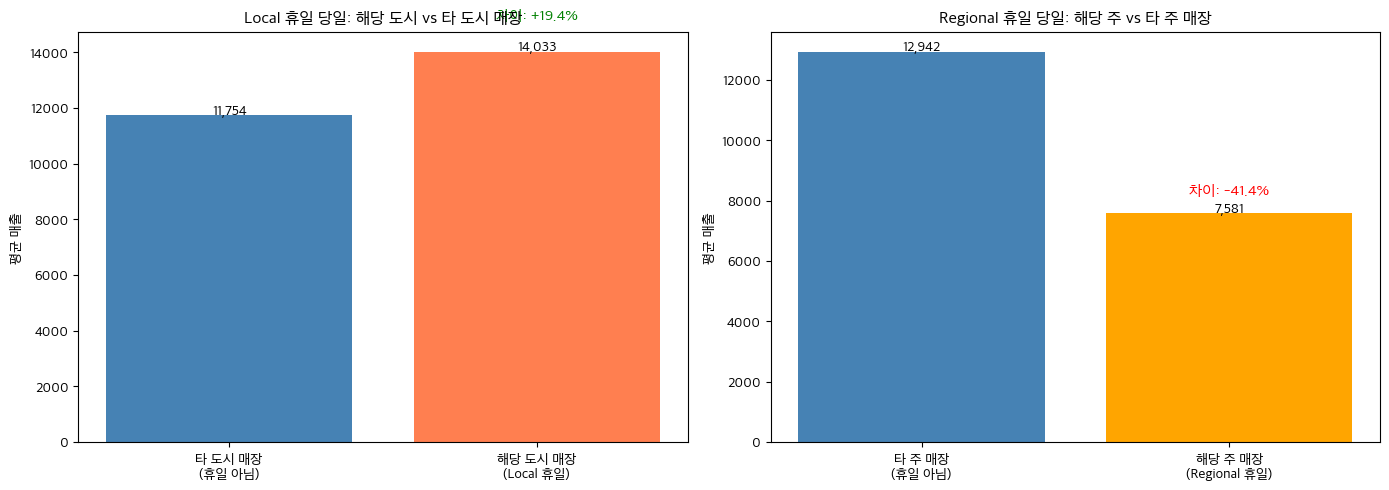

In [99]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Local 휴일: 해당 도시 vs 타 도시
x_local = ['타 도시 매장\n(휴일 아님)', '해당 도시 매장\n(Local 휴일)']
y_local = [local_comparison[local_comparison['is_affected']==False]['avg_sales'].values[0],
           local_comparison[local_comparison['is_affected']==True]['avg_sales'].values[0]]
colors_local = ['steelblue', 'coral']

bars = axes[0].bar(x_local, y_local, color=colors_local)
axes[0].set_title('Local 휴일 당일: 해당 도시 vs 타 도시 매장', fontsize=12, fontweight='bold')
axes[0].set_ylabel('평균 매출')

diff_local = (y_local[1] - y_local[0]) / y_local[0] * 100
for bar, val in zip(bars, y_local):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, f'{val:,.0f}', ha='center', fontsize=10)
axes[0].text(1, y_local[1] * 1.08, f'차이: {diff_local:+.1f}%', ha='center', fontsize=11, fontweight='bold',
            color='red' if diff_local < 0 else 'green')

# 2. Regional 휴일: 해당 주 vs 타 주
x_regional = ['타 주 매장\n(휴일 아님)', '해당 주 매장\n(Regional 휴일)']
y_regional = [regional_comparison[regional_comparison['is_affected']==False]['avg_sales'].values[0],
              regional_comparison[regional_comparison['is_affected']==True]['avg_sales'].values[0]]
colors_regional = ['steelblue', 'orange']

bars = axes[1].bar(x_regional, y_regional, color=colors_regional)
axes[1].set_title('Regional 휴일 당일: 해당 주 vs 타 주 매장', fontsize=12, fontweight='bold')
axes[1].set_ylabel('평균 매출')

diff_regional = (y_regional[1] - y_regional[0]) / y_regional[0] * 100
for bar, val in zip(bars, y_regional):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, f'{val:,.0f}', ha='center', fontsize=10)
axes[1].text(1, y_regional[1] * 1.08, f'차이: {diff_regional:+.1f}%', ha='center', fontsize=11, fontweight='bold',
            color='red' if diff_regional < 0 else 'green')

plt.tight_layout()
plt.show()


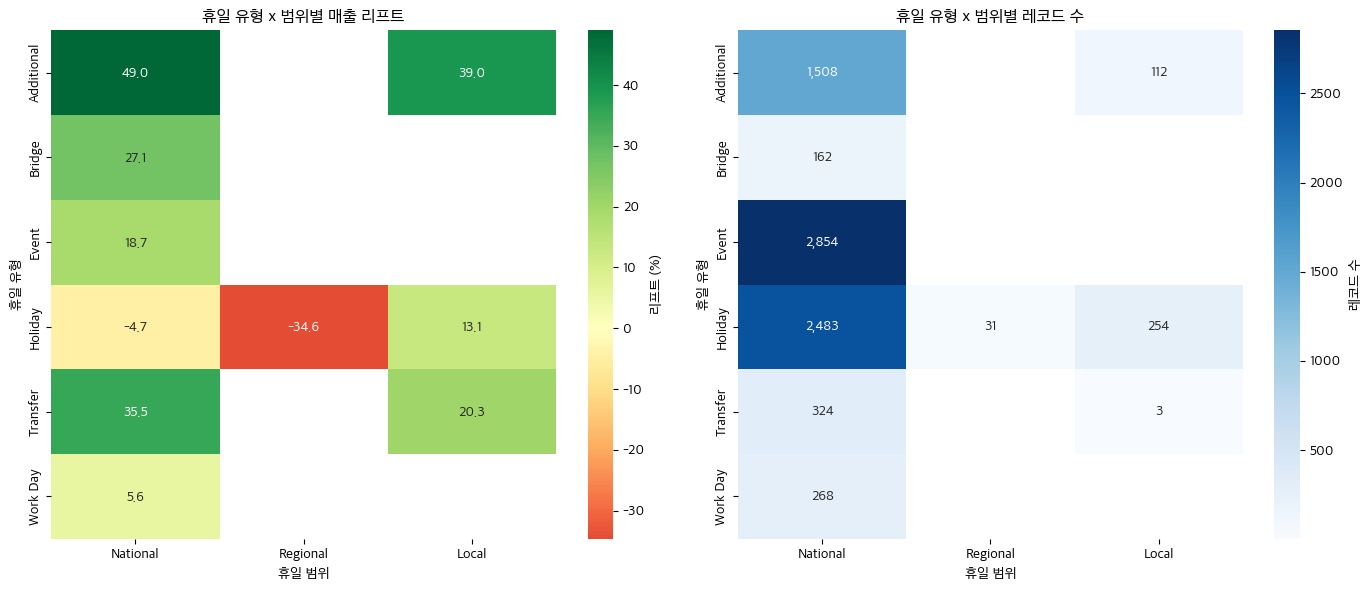

,locale,type,avg_sales,count,lift_pct
0,Local,Additional,16122.471305,112,39.047012
1,Local,Holiday,13113.318695,254,13.094807
2,Local,Transfer,13945.099337,3,20.268435
3,National,Additional,17277.760407,1508,49.010714
4,National,Bridge,14742.778181,162,27.147955
5,National,Event,13763.269662,2854,18.700259
6,National,Holiday,11051.869612,2483,-4.684002
7,National,Transfer,15711.584612,324,35.503351
8,National,Work Day,12244.654066,268,5.603076
9,Regional,Holiday,7580.939580,31,-34.618770


In [100]:
# ============================================================================
# Step 4: 휴일 유형(type)별 지역 효과 분석
# ============================================================================

# 휴일 유형별로 해당 지역 매장 매출 분석
holiday_type_locale = store_daily_sales[store_daily_sales['is_any_holiday']].groupby(
    ['holiday_locale', 'holiday_type']
)['sales'].agg(['mean', 'count']).reset_index()
holiday_type_locale.columns = ['locale', 'type', 'avg_sales', 'count']
holiday_type_locale['lift_pct'] = (holiday_type_locale['avg_sales'] - non_holiday_avg) / non_holiday_avg * 100

# 히트맵 데이터 준비
heatmap_data = holiday_type_locale.pivot(index='type', columns='locale', values='lift_pct')
heatmap_count = holiday_type_locale.pivot(index='type', columns='locale', values='count')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. 휴일 유형 x 범위별 매출 리프트 히트맵
sns.heatmap(heatmap_data[['National', 'Regional', 'Local']], annot=True, fmt='.1f', 
            cmap='RdYlGn', center=0, ax=axes[0], cbar_kws={'label': '리프트 (%)'})
axes[0].set_title('휴일 유형 x 범위별 매출 리프트', fontsize=12, fontweight='bold')
axes[0].set_xlabel('휴일 범위')
axes[0].set_ylabel('휴일 유형')

# 2. 휴일 유형 x 범위별 데이터 수
sns.heatmap(heatmap_count[['National', 'Regional', 'Local']], annot=True, fmt=',.0f',
            cmap='Blues', ax=axes[1], cbar_kws={'label': '레코드 수'})
axes[1].set_title('휴일 유형 x 범위별 레코드 수', fontsize=12, fontweight='bold')
axes[1].set_xlabel('휴일 범위')
axes[1].set_ylabel('휴일 유형')

plt.tight_layout()
plt.show()

# 휴일 유형별 지역 효과 요약
display(holiday_type_locale)

In [101]:
# ============================================================================
# Step 5: 지역별 휴일 전후 패턴 (D-3 ~ D+3)
# ============================================================================

def get_store_holiday_window(store_daily_df, holiday_df, locale_col, window=3):
    """특정 휴일 기준 매장별 전후 매출 패턴"""
    results = []
    for _, hrow in holiday_df.iterrows():
        hdate = hrow['date']
        for offset in range(-window, window + 1):
            target_date = hdate + pd.Timedelta(days=offset)
            # 해당 날짜의 모든 매장 매출
            day_sales = store_daily_df[store_daily_df['date'] == target_date]
            if not day_sales.empty:
                for _, srow in day_sales.iterrows():
                    results.append({
                        'offset': offset,
                        'sales': srow['sales'],
                        'store_nbr': srow['store_nbr'],
                        'holiday_date': hdate
                    })
    return pd.DataFrame(results)



In [102]:
# National 휴일 기준 전후 패턴 (전국 합계)
national_window_data = []
for hdate in national_holidays['date']:
    for offset in range(-3, 4):
        target_date = hdate + pd.Timedelta(days=offset)
        day_sales = store_daily_sales[store_daily_sales['date'] == target_date]['sales'].sum()
        if day_sales > 0:
            national_window_data.append({'offset': offset, 'sales': day_sales, 'locale': 'National'})

national_window_df = pd.DataFrame(national_window_data)
national_pattern = national_window_df.groupby('offset')['sales'].mean()

# Local 휴일 기준: 해당 도시 매장만의 전후 패턴
local_window_data = []
for _, hrow in local_holidays.iterrows():
    hdate = hrow['date']
    hcity = hrow['locale_name']
    for offset in range(-3, 4):
        target_date = hdate + pd.Timedelta(days=offset)
        # 해당 도시 매장만
        city_sales = store_daily_sales[(store_daily_sales['date'] == target_date) & 
                                        (store_daily_sales['city'] == hcity)]['sales'].sum()
        if city_sales > 0:
            local_window_data.append({'offset': offset, 'sales': city_sales, 'locale': 'Local', 'city': hcity})

local_window_df = pd.DataFrame(local_window_data)
local_pattern = local_window_df.groupby('offset')['sales'].mean()


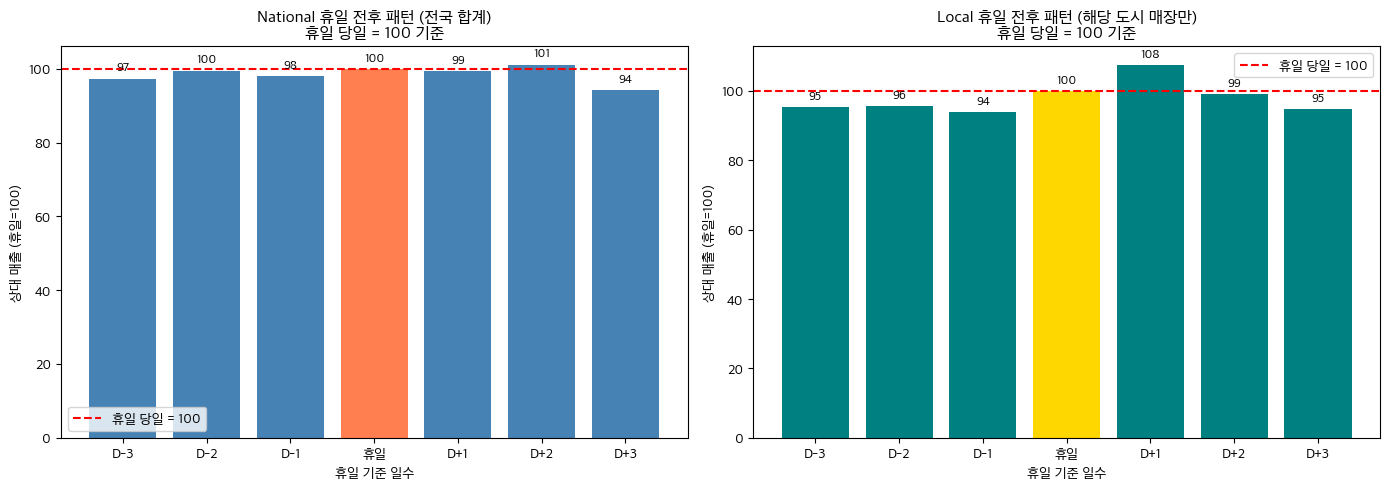

In [103]:
# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. National 휴일 전후 패턴 (전국)
national_normalized = national_pattern / national_pattern[0] * 100
bars = axes[0].bar(national_normalized.index, national_normalized.values, 
                   color=['coral' if i == 0 else 'steelblue' for i in national_normalized.index])
axes[0].axhline(y=100, color='red', linestyle='--', linewidth=1.5, label='휴일 당일 = 100')
axes[0].set_title('National 휴일 전후 패턴 (전국 합계)\n휴일 당일 = 100 기준', fontsize=12, fontweight='bold')
axes[0].set_xlabel('휴일 기준 일수')
axes[0].set_ylabel('상대 매출 (휴일=100)')
axes[0].set_xticks(range(-3, 4))
axes[0].set_xticklabels(['D-3', 'D-2', 'D-1', '휴일', 'D+1', 'D+2', 'D+3'])
axes[0].legend()

for i, v in zip(national_normalized.index, national_normalized.values):
    axes[0].text(i, v + 2, f'{v:.0f}', ha='center', fontsize=9)

# 2. Local 휴일 전후 패턴 (해당 도시만)
local_normalized = local_pattern / local_pattern[0] * 100
bars = axes[1].bar(local_normalized.index, local_normalized.values,
                   color=['gold' if i == 0 else 'teal' for i in local_normalized.index])
axes[1].axhline(y=100, color='red', linestyle='--', linewidth=1.5, label='휴일 당일 = 100')
axes[1].set_title('Local 휴일 전후 패턴 (해당 도시 매장만)\n휴일 당일 = 100 기준', fontsize=12, fontweight='bold')
axes[1].set_xlabel('휴일 기준 일수')
axes[1].set_ylabel('상대 매출 (휴일=100)')
axes[1].set_xticks(range(-3, 4))
axes[1].set_xticklabels(['D-3', 'D-2', 'D-1', '휴일', 'D+1', 'D+2', 'D+3'])
axes[1].legend()

for i, v in zip(local_normalized.index, local_normalized.values):
    axes[1].text(i, v + 2, f'{v:.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# National 휴일 (전국):
for offset in range(-3, 4):
    val = national_normalized[offset]
    #   D{offset:+d}: {val:.1f}% {
for offset in range(-3, 4):
    val = local_normalized[offset]
    #   D{offset:+d}: {val:.1f}% {

In [ ]:
# 1.3.4 분석 결과 CSV 저장
promo_comparison.to_csv(f'{EXPORT_PATH}holiday_promo_comparison.csv')

no_promo_df = pd.DataFrame({
    'holiday_status': no_promo_comparison.index,
    'avg_sales': no_promo_comparison.values
})
no_promo_df.to_csv(f'{EXPORT_PATH}holiday_pure_effect.csv', index=False)

holiday_pattern_df = pd.DataFrame({
    'offset': range(-3, 4),
    'national_avg_sales': national_pattern.values,
    'local_avg_sales': local_pattern.values
})
holiday_pattern_df.to_csv(f'{EXPORT_PATH}holiday_pattern_d3.csv', index=False)

print(f"1.3.4 CSV 저장 완료: {EXPORT_PATH}")

## 1.3.4 휴일·이벤트 효과 (매장-지역 수준)

### 분석 요약 표 (매장-지역 수준)

| 분석 항목 | 핵심 발견 | 비즈니스 시사점 |
|----------|----------|----------------|
| **휴일 범위별 효과** | Local +21.0%, National +17.5%, Regional -34.6% (31건) | 표면적으로 Local/National 휴일에 매출 증가 |
| **Local 휴일 효과** | 해당 도시 매장 +19.4% vs 타 도시 | 지역 축제/기념일에 매출 높음 |
| **휴일 유형별** | Additional +49%, Transfer +35%, Bridge +27% | 연휴/징검다리 휴일에 매출 높음 |
| **프로모션 교란 검증** | 휴일에 프로모션 +0.82개 더 많음, 프로모션=0 시 휴일 효과 -6.2% | 휴일-프로모션 관계 추가 분석 필요 |

### 1. 표면적 휴일 효과 (범위·지역·유형)
- 표와 같이 **Local / National**은 플러스 방향이 크고, **Regional**은 **-34.6%**로 나오나 관측이 **31건** 수준이라 **정의·표본**을 함께 보고 해석해야 함
- **해당 도시 Local 휴일** 매장은 타 도시 대비 **+19.4%**로, **지역 이벤트**가 매출에 미치는 영향이 뚜렷함
- **Additional / Transfer / Bridge** 등 연휴·징검다리 성격의 휴일 유형에서 상대적으로 매출이 두드러짐

### 2. 프로모션 교란(Confounding)과 순수 휴일 효과
- 휴일에는 비휴일 대비 평균 **프로모션 품목 수**가 더 많음 (**2.50개 → 3.32개**, **+0.82개**, 약 **33%** 증가)
- **프로모션=0**인 날만 보면 순수 휴일 효과는 약 **-6.2%**로, **휴일만 분리하면 매출이 낮아지는** 방향
- 표면의 “휴일 매출 증가”는 **휴일에 겹친 프로모션·행사**가 크게 개입했을 가능성이 큼

### 3. 핵심 정리 (한눈에)
- Local/National 휴일에는 매출이 높게 보임 (**약 +17~21%**)
- 다만 휴일에 프로모션이 **비휴일 2.5개 → 휴일 3.3개** 수준으로 더 집행됨
- 프로모션을 통제한 관점에서는 휴일 효과가 **-6.2%**로 나타나 **“휴일 자체”와 “프로모션”을 분리**해 볼 필요가 있음

### 4. 전략적 권고
1. 휴일 매출 증가가 **휴일 자체**인지 **프로모션 효과**인지 **추가 검증**이 필요함
2. 현재 데이터만으로 **휴일 프로모션 ROI**를 정확히 단정하기는 어려움
3. **후속 분석 권장**: 동일 프로모션 수준에서 휴일/비휴일 비교, 휴일별 프로모션 효율 분석, **1.4.2 클러스터 교차분석** 등으로 순효과를 계속 분리함

In [ ]:
md_parts.append("""
## 1.3.4 휴일·이벤트 효과 (매장-지역 수준)

### 분석 요약 표 (매장-지역 수준)

| 분석 항목 | 핵심 발견 | 비즈니스 시사점 |
|----------|----------|----------------|
| **휴일 범위별 효과** | Local +21.0%, National +17.5%, Regional -34.6% (31건) | 표면적으로 Local/National 휴일에 매출 증가 |
| **Local 휴일 효과** | 해당 도시 매장 +19.4% vs 타 도시 | 지역 축제/기념일에 매출 높음 |
| **휴일 유형별** | Additional +49%, Transfer +35%, Bridge +27% | 연휴/징검다리 휴일에 매출 높음 |
| **프로모션 교란 검증** | 휴일에 프로모션 +0.82개 더 많음, 프로모션=0 시 휴일 효과 -6.2% | 휴일-프로모션 관계 추가 분석 필요 |

### 1. 표면적 휴일 효과 (범위·지역·유형)
- 표와 같이 **Local / National**은 플러스 방향이 크고, **Regional**은 **-34.6%**로 나오나 관측이 **31건** 수준이라 **정의·표본**을 함께 보고 해석해야 함
- **해당 도시 Local 휴일** 매장은 타 도시 대비 **+19.4%**로, **지역 이벤트**가 매출에 미치는 영향이 뚜렷함
- **Additional / Transfer / Bridge** 등 연휴·징검다리 성격의 휴일 유형에서 상대적으로 매출이 두드러짐

### 2. 프로모션 교란(Confounding)과 순수 휴일 효과
- 휴일에는 비휴일 대비 평균 **프로모션 품목 수**가 더 많음 (**2.50개 → 3.32개**, **+0.82개**, 약 **33%** 증가)
- **프로모션=0**인 날만 보면 순수 휴일 효과는 약 **-6.2%**로, **휴일만 분리하면 매출이 낮아지는** 방향
- 표면의 “휴일 매출 증가”는 **휴일에 겹친 프로모션·행사**가 크게 개입했을 가능성이 큼

### 3. 핵심 정리 (한눈에)
- Local/National 휴일에는 매출이 높게 보임 (**약 +17~21%**)
- 다만 휴일에 프로모션이 **비휴일 2.5개 → 휴일 3.3개** 수준으로 더 집행됨
- 프로모션을 통제한 관점에서는 휴일 효과가 **-6.2%**로 나타나 **“휴일 자체”와 “프로모션”을 분리**해 볼 필요가 있음

### 4. 전략적 권고
1. 휴일 매출 증가가 **휴일 자체**인지 **프로모션 효과**인지 **추가 검증**이 필요함
2. 현재 데이터만으로 **휴일 프로모션 ROI**를 정확히 단정하기는 어려움
3. **후속 분석 권장**: 동일 프로모션 수준에서 휴일/비휴일 비교, 휴일별 프로모션 효율 분석, **1.4.2 클러스터 교차분석** 등으로 순효과를 계속 분리함
""")
print(f"md_parts 누적 완료 ({len(md_parts)}개)")

**휴일/이벤트 효과 분석 요약 (매장-지역 수준)**

| 분석 항목 | 핵심 발견 | 비즈니스 시사점 |
|----------|----------|----------------|
| **휴일 범위별 효과** | Local +21.0%, National +17.5%, Regional -34.6% (31건) | 표면적으로 Local/National 휴일에 매출 증가 |
| **Local 휴일 효과** | 해당 도시 매장 +19.4% vs 타 도시 | 지역 축제/기념일에 매출 높음 |
| **휴일 유형별** | Additional +49%, Transfer +35%, Bridge +27% | 연휴/징검다리 휴일에 매출 높음 |
| **프로모션 교란 검증** | 휴일에 프로모션 +0.82개 더 많음, 프로모션=0 시 휴일 효과 -6.2% | **휴일-프로모션 관계 추가 분석 필요** |

> **핵심 인사이트:**
> - Local/National 휴일에 매출이 높게 나타남 (+17~21%)
> - 단, 휴일에 프로모션이 더 많이 집행됨 (비휴일 2.5개  휴일 3.3개)
> - 프로모션=0인 날 비교 시 휴일 효과 -6.2%로 나타남
> - **휴일과 프로모션 간의 관계 추가 분석 필요** 

> **전략적 권고:**
> 1. 휴일 매출 증가가 "휴일 자체" vs "프로모션 효과"인지 **추가 검증 필요**
> 2. 현재 데이터로는 휴일 프로모션 전략의 ROI를 정확히 산출하기 어려움
> 3. **후속 분석 권장**: 동일 프로모션 수준에서 휴일/비휴일 비교, 휴일별 프로모션 효율성 분석

### 1.3.5 유가-매출 관계 분석

에콰도르는 산유국이므로 **유가 변동이 국가 경제와 소비에 직접 영향**을 줄 수 있습니다. 유가와 매출의 상관관계를 분석하되, **허위 상관(Spurious Correlation)**에 주의해야 합니다 — 두 변수가 동시에 증가한다고 해서 반드시 인과관계가 있는 것은 아닙니다.

유가 데이터는 매일 기록되지 않으므로 `merge_asof()`로 가장 최근 유가를 매칭합니다.

> 참고: [merge_asof 실전 가이드 (Python in Plain English)](https://python.plainenglish.io/why-asof-join-or-merge-asof-is-the-most-underrated-function-in-python-b918db542e7f)


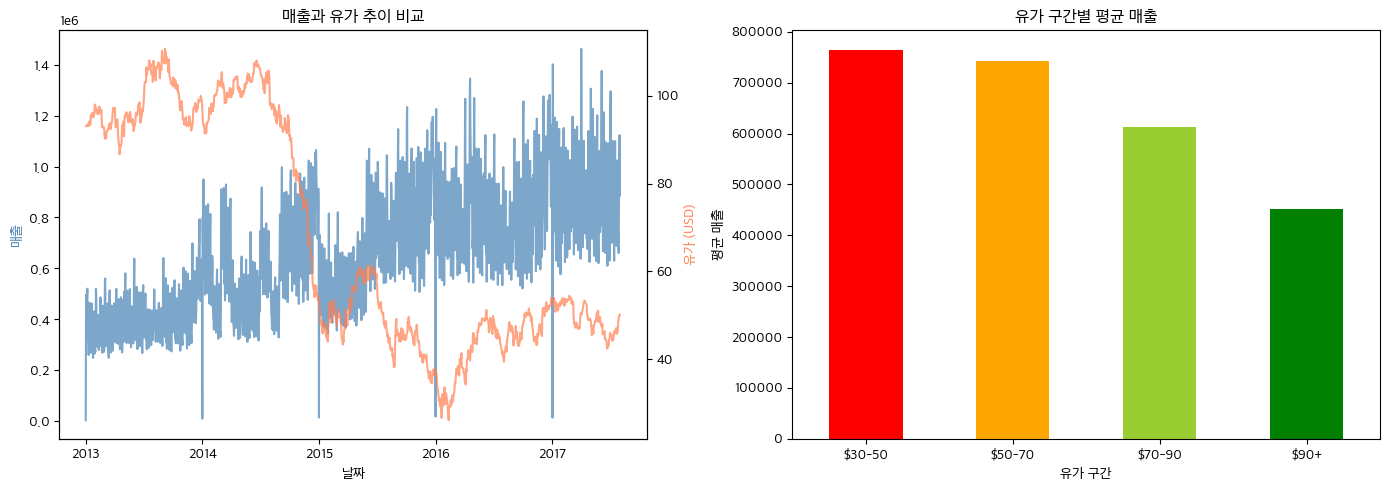

In [104]:
# 유가와 매출 상관관계 분석
oil_filled = oil.copy()
oil_filled['dcoilwtico'] = oil_filled['dcoilwtico'].interpolate(method='linear')

sales_oil = daily_sales.merge(oil_filled, on='date', how='left')
sales_oil['dcoilwtico'] = sales_oil['dcoilwtico'].interpolate(method='linear')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. 유가 vs 매출 시계열
ax1 = axes[0]
ax2 = ax1.twinx()
ax1.plot(sales_oil['date'], sales_oil['total_sales'], color='steelblue', label='매출', alpha=0.7)
ax2.plot(sales_oil['date'], sales_oil['dcoilwtico'], color='coral', label='유가', alpha=0.7)
ax1.set_xlabel('날짜')
ax1.set_ylabel('매출', color='steelblue')
ax2.set_ylabel('유가 (USD)', color='coral')
ax1.set_title('매출과 유가 추이 비교', fontsize=12, fontweight='bold')

# 2. 유가 구간별 평균 매출
sales_oil['oil_regime'] = pd.cut(sales_oil['dcoilwtico'], 
                                  bins=[0, 50, 70, 90, 120],
                                  labels=['$30-50', '$50-70', '$70-90', '$90+'])
regime_stats = sales_oil.groupby('oil_regime', observed=True)['total_sales'].mean()
colors_regime = ['red', 'orange', 'yellowgreen', 'green']
regime_stats.plot(kind='bar', ax=axes[1], color=colors_regime)
axes[1].set_title('유가 구간별 평균 매출', fontsize=12, fontweight='bold')
axes[1].set_xlabel('유가 구간')
axes[1].set_ylabel('평균 매출')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# 상관계수
correlation = sales_oil[['total_sales', 'dcoilwtico']].corr().iloc[0, 1]

**유가-매출 관계 해석**

- **상관계수**: 약 -0.63으로 음의 상관관계
- **주의**: 이는 "허위 상관(Spurious Correlation)" 가능성이 높음
  - 유가 하락 시기(2014~2016)와 매출 성장 시기가 우연히 겹침
  - 시간에 따른 추세가 반영된 결과
- **참고**: 에콰도르는 산유국으로 고유가 시 경제지표가 좋아지는 것이 일반적

### 1.3.6 성장 기여도 분석

**성장 기여도 분석**은 전체 매출 성장에 각 카테고리(또는 세그먼트)가 얼마나 기여했는지 분해한다:

```
카테고리 기여도 = (카테고리 매출 변화량) / (전체 매출 변화량) × 100
```

이를 통해 "전체 매출이 5% 성장했는데, 그 중 3%p는 GROCERY I 덕분"과 같은 인사이트를 도출합니다. 성장을 이끄는 카테고리와 발목을 잡는 카테고리를 구분하여 자원 배분 의사결정에 활용합니다.


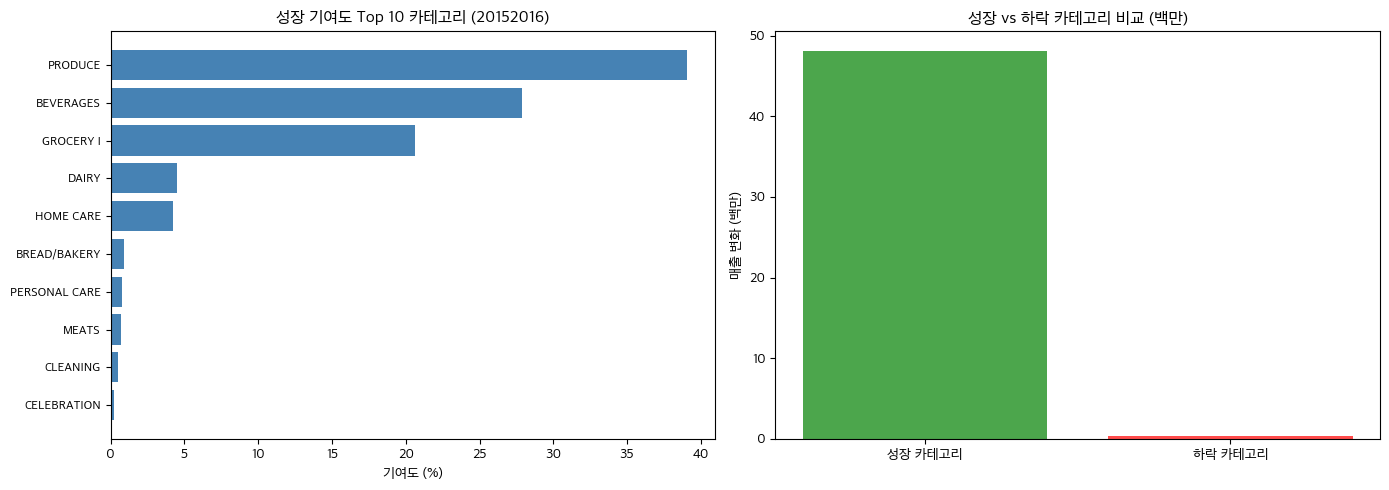

In [105]:
# 성장 기여도 분석 (2015  2016)
yearly_cat = train[train['year'].isin([2015, 2016])].groupby(['year', 'family'])['sales'].sum().unstack(level=0)
yearly_cat['growth'] = yearly_cat[2016] - yearly_cat[2015]

total_growth = yearly_cat['growth'].sum()
yearly_cat['contribution'] = (yearly_cat['growth'] / total_growth) * 100
yearly_cat = yearly_cat.sort_values('contribution', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. 기여도 Top 10
top10 = yearly_cat.head(10)
axes[0].barh(range(len(top10)), top10['contribution'], color='steelblue')
axes[0].set_yticks(range(len(top10)))
axes[0].set_yticklabels(top10.index, fontsize=9)
axes[0].set_xlabel('기여도 (%)')
axes[0].set_title('성장 기여도 Top 10 카테고리 (20152016)', fontsize=12, fontweight='bold')
axes[0].invert_yaxis()

# 2. 성장 vs 하락 카테고리
positive = yearly_cat[yearly_cat['growth'] > 0]['growth'].sum()
negative = yearly_cat[yearly_cat['growth'] < 0]['growth'].sum()

axes[1].bar(['성장 카테고리', '하락 카테고리'], [positive/1e6, abs(negative)/1e6], 
            color=['green', 'red'], alpha=0.7)
axes[1].set_title('성장 vs 하락 카테고리 비교 (백만)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('매출 변화 (백만)')

plt.tight_layout()
plt.show()

## 1.3.5~1.3.6 유가-매출 관계 및 성장 기여도

### 핵심 인사이트
- 유가와 매출의 상관계수는 약 -0.63으로 음의 상관이나, 직접 인과보다 공통 요인·허위 상관 가능성에 유의해야 함
- 카테고리별 성장 기여도가 다르며 상위 카테고리가 전체 성장을 주도하는 경향이 있음
- 일부 카테고리는 성장 기여가 음(-)일 수 있어 포트폴리오·원인 분석이 필요함

In [ ]:
md_parts.append("""
## 1.3.5~1.3.6 유가-매출 관계 및 성장 기여도

### 핵심 인사이트
- 유가와 매출의 상관계수는 약 -0.63으로 음의 상관이나, 직접 인과보다 공통 요인·허위 상관 가능성에 유의해야 함
- 카테고리별 성장 기여도가 다르며 상위 카테고리가 전체 성장을 주도하는 경향이 있음
- 일부 카테고리는 성장 기여가 음(-)일 수 있어 포트폴리오·원인 분석이 필요함
""")
print(f"md_parts 누적 완료 ({len(md_parts)}개)")

## 1.4 세그먼트별 심화 분석

매장 클러스터, 타입, 도시별로 세분화하여 분석합니다.

In [106]:
# 매장별 매출 데이터 생성
store_sales = train_merged.groupby(['store_nbr', 'date'])['sales'].sum().reset_index()
store_sales = store_sales.merge(stores, on='store_nbr', how='left')

### 1.4.1 Cluster별 매출 분석

Corporación Favorita는 매장을 특성에 따라 **17개 클러스터**로 분류합니다. 클러스터별 매출 규모와 성장률을 비교하면 어떤 매장 그룹이 성장을 주도하고, 어떤 그룹이 뒤처지는지 파악할 수 있습니다. 이는 매장별 차별화 전략(프로모션, 상품 구성, 운영 시간 등)의 근거가 됩니다.


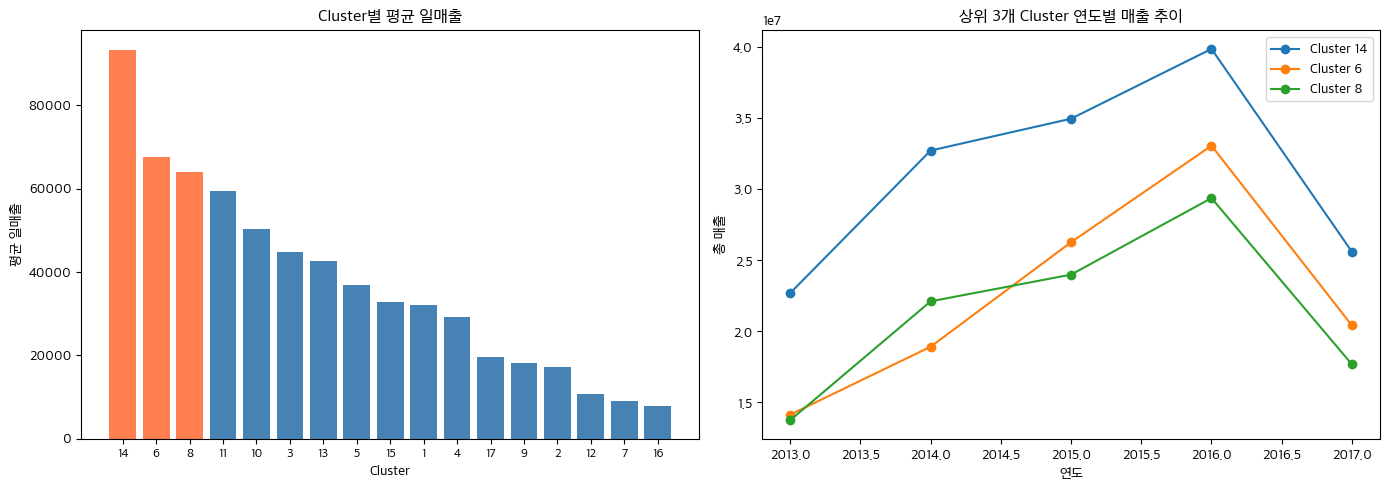

In [107]:
# Cluster별 매출 분석
cluster_daily = store_sales.groupby(['cluster', 'date'])['sales'].sum().reset_index()
cluster_daily['year'] = cluster_daily['date'].dt.year

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Cluster별 평균 일매출
cluster_avg = cluster_daily.groupby('cluster')['sales'].mean().sort_values(ascending=False)
colors = ['coral' if i < 3 else 'steelblue' for i in range(len(cluster_avg))]
axes[0].bar(range(len(cluster_avg)), cluster_avg.values, color=colors)
axes[0].set_xticks(range(len(cluster_avg)))
axes[0].set_xticklabels(cluster_avg.index, fontsize=9)
axes[0].set_title('Cluster별 평균 일매출', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('평균 일매출')

# 2. 상위 3개 Cluster YoY 추이
top3_clusters = cluster_avg.head(3).index.tolist()
cluster_yearly = cluster_daily[cluster_daily['cluster'].isin(top3_clusters)].groupby(['year', 'cluster'])['sales'].sum().unstack()

for cluster in top3_clusters:
    if cluster in cluster_yearly.columns:
        axes[1].plot(cluster_yearly.index, cluster_yearly[cluster], marker='o', label=f'Cluster {cluster}')

axes[1].set_title('상위 3개 Cluster 연도별 매출 추이', fontsize=12, fontweight='bold')
axes[1].set_xlabel('연도')
axes[1].set_ylabel('총 매출')
axes[1].legend()

plt.tight_layout()
plt.show()

### 1.4.2 클러스터별 휴일 × 프로모션 교차 분석

1.3.4에서 발견한 "휴일-프로모션 관계 추가 분석 필요"에 대한 후속 분석입니다.
클러스터별로 휴일과 프로모션의 개별 효과 및 시너지 효과를 분석합니다.

In [108]:
# ============================================================================
# 클러스터별 휴일 × 프로모션 교차 분석 (2x2 분석)
# ============================================================================
# [ 분석 목적 ]
# 1.3.4에서 발견한 "휴일-프로모션 관계 추가 분석 필요"에 대한 후속 분석
# 휴일 매출 증가가 "휴일 자체"인지 "프로모션 효과"인지 클러스터별로 분리
# [ 2x2 매트릭스 ]
#                 프로모션 無    프로모션 有
#    비휴일          A              B
#    휴일            C              D
# [ 효과 분해 ]
# - 순수 프로모션 효과 = B - A (비휴일에서 프로모션 효과)
# - 순수 휴일 효과 = C - A (프로모션 없을 때 휴일 효과)
# ============================================================================

# 1. 데이터 준비: train_merged에 휴일 플래그 추가
train_merged['has_promo'] = (train_merged['onpromotion'].fillna(0) > 0).astype(int)

# 휴일 플래그 연결 (store_daily_sales에서 가져옴)
holiday_flags = store_daily_sales[['date', 'store_nbr', 'is_any_holiday']].drop_duplicates()
train_merged = train_merged.merge(holiday_flags, on=['date', 'store_nbr'], how='left')
train_merged['is_any_holiday'] = train_merged['is_any_holiday'].fillna(False)


In [109]:
# 2. 클러스터별 2x2 교차 분석
results = []
for cluster in sorted(train_merged['cluster'].unique()):
    cluster_data = train_merged[train_merged['cluster'] == cluster]
    
    # 2x2 매트릭스: (휴일 여부) × (프로모션 여부) - 평균 매출 및 row 수
    A_data = cluster_data[(~cluster_data['is_any_holiday']) & (cluster_data['has_promo'] == 0)]['sales']
    B_data = cluster_data[(~cluster_data['is_any_holiday']) & (cluster_data['has_promo'] == 1)]['sales']
    C_data = cluster_data[(cluster_data['is_any_holiday']) & (cluster_data['has_promo'] == 0)]['sales']
    D_data = cluster_data[(cluster_data['is_any_holiday']) & (cluster_data['has_promo'] == 1)]['sales']
    
    A, A_n = A_data.mean(), len(A_data)  # 비휴일, 프로모션X
    B, B_n = B_data.mean(), len(B_data)  # 비휴일, 프로모션O
    C, C_n = C_data.mean(), len(C_data)  # 휴일, 프로모션X
    D, D_n = D_data.mean(), len(D_data)  # 휴일, 프로모션O
    
    # 효과 분해
    promo_effect = B - A if pd.notna(B) and pd.notna(A) else 0        # 순수 프로모션 효과
    holiday_effect = C - A if pd.notna(C) and pd.notna(A) else 0      # 순수 휴일 효과
    
    results.append({
        'cluster': int(cluster),
        'A_비휴일_프로모X': A, 'A_n': A_n,
        'B_비휴일_프로모O': B, 'B_n': B_n,
        'C_휴일_프로모X': C, 'C_n': C_n,
        'D_휴일_프로모O': D, 'D_n': D_n,
        'promo_effect': promo_effect,
        'holiday_effect': holiday_effect
    })

effect_df = pd.DataFrame(results)


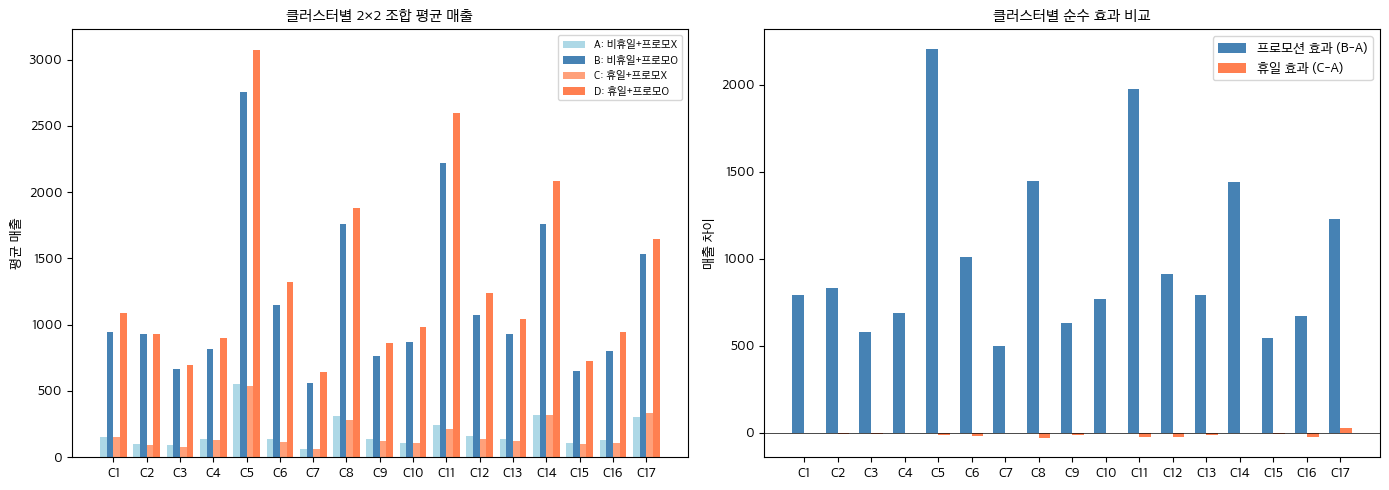

In [110]:
# 3. 데이터 양 확인 (A, B, C, D row 수)
# [ 데이터 양 확인: 클러스터별 A/B/C/D row 수 ]
for _, row in effect_df.iterrows():
    warning = ""
    if row['C_n'] < 100 or row['D_n'] < 100:
        warning = "  휴일 데이터 부족"

# 전체 합계
total_A = effect_df['A_n'].sum()
total_B = effect_df['B_n'].sum()
total_C = effect_df['C_n'].sum()
total_D = effect_df['D_n'].sum()

# 4. 시각화 (2x2 + 1x1 레이아웃)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 4-1. 클러스터별 2x2 매트릭스 평균 매출
ax = axes[0]
x = range(len(effect_df))
width = 0.2
ax.bar([i - 1.5*width for i in x], effect_df['A_비휴일_프로모X'], width, label='A: 비휴일+프로모X', color='lightblue')
ax.bar([i - 0.5*width for i in x], effect_df['B_비휴일_프로모O'], width, label='B: 비휴일+프로모O', color='steelblue')
ax.bar([i + 0.5*width for i in x], effect_df['C_휴일_프로모X'], width, label='C: 휴일+프로모X', color='lightsalmon')
ax.bar([i + 1.5*width for i in x], effect_df['D_휴일_프로모O'], width, label='D: 휴일+프로모O', color='coral')
ax.set_xticks(x)
ax.set_xticklabels([f'C{c}' for c in effect_df['cluster']])
ax.set_title('클러스터별 2×2 조합 평균 매출', fontsize=11, fontweight='bold')
ax.set_ylabel('평균 매출')
ax.legend(loc='upper right', fontsize=8)

# 4-2. 순수 프로모션 효과 vs 순수 휴일 효과
ax = axes[1]
x = range(len(effect_df))
width = 0.35
ax.bar([i - width/2 for i in x], effect_df['promo_effect'], width, label='프로모션 효과 (B-A)', color='steelblue')
ax.bar([i + width/2 for i in x], effect_df['holiday_effect'], width, label='휴일 효과 (C-A)', color='coral')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels([f'C{c}' for c in effect_df['cluster']])
ax.set_title('클러스터별 순수 효과 비교', fontsize=11, fontweight='bold')
ax.set_ylabel('매출 차이')
ax.legend()

plt.tight_layout()
plt.show()


아래 **1.4.1~1.4.2 인사이트** 셀에 요약 표·핵심 정리·전략적 시사를 **1.3.4와 같은 형식**으로 통합해 두었습니다.


In [ ]:
# 1.4.1~2 분석 결과 CSV 저장
cluster_summary = cluster_daily.groupby('cluster')['sales'].agg(['mean', 'sum', 'count']).reset_index()
cluster_summary.columns = ['cluster', 'avg_daily_sales', 'total_sales', 'days']
cluster_summary.to_csv(f'{EXPORT_PATH}cluster_sales.csv', index=False)

effect_df.to_csv(f'{EXPORT_PATH}cluster_holiday_promo.csv', index=False)

print(f"1.4.1~2 CSV 저장 완료: {EXPORT_PATH}")

## 1.4.1~1.4.2 클러스터별 매출 및 휴일×프로모션 교차

### 분석 요약 표 (클러스터 휴일×프로모션)

| 효과 | 계산 방법 | 결과 |
|------|----------|------|
| **순수 프로모션 효과** | B - A | 모든 클러스터에서 **+500 ~ +3,000** (강한 양의 효과) |
| **순수 휴일 효과** | C - A | 모든 클러스터에서 **0 또는 음(-)** |

### 1. 클러스터 간 매출·패턴 편차
- **17개 클러스터** 간 매출 규모와 패턴 편차가 큼
- 클러스터별 효과 크기가 달라 **세그먼트별 프로모션·마케팅 집중도**를 조정할 여지가 있음

### 2. 2×2 교차 효과 (프로모션 vs 순수 휴일)
- **프로모션 효과(B−A)**는 클러스터 **전반에서 양(+)**
- **순수 휴일 효과(C−A)**는 **0 이하인 경우가 많음** → 표와 같이 **순수 휴일만으로는 매출을 끌어올리기 어렵다**는 방향
- **C5, C8, C11** 등 고매출 클러스터에서 **프로모션 효과가 특히 큼**

### 3. 핵심 정리 (1.3.4와의 일치)
- **프로모션 효과**: 모든 클러스터에서 일관되게 강한 **양(+)**
- **휴일 효과**: 모든 클러스터에서 거의 **0 또는 음(−)** → **순수 휴일 효과는 거의 없음**으로 해석 가능
- 휴일 매출 증가는 **「휴일 자체」가 아닌 「프로모션 효과」**에 가깝고, 휴일에 프로모션 없이는 매출 증가 효과를 기대하기 어려움
- **모든 클러스터에서 휴일 프로모션 필수**라는 실무 함의와 연결됨

### 4. 전략적 시사
1. 고효과 클러스터(C5, C8, C11 등)에 **프로모션·행사 자원**을 상대적으로 집중하는 방안 검토
2. 휴일 캘린더·목표 설정 시 **순휴일 효과만**으로 기대치를 세우기보다 **프로모션 연계**를 전제로 계획
3. **1.3.4**의 교란 검증과 병행해, 세그먼트·조건별 **ROI·실험**으로 휴일×프로모션 조합을 지속 검증

In [ ]:
md_parts.append("""
## 1.4.1~1.4.2 클러스터별 매출 및 휴일×프로모션 교차

### 분석 요약 표 (클러스터 휴일×프로모션)

| 효과 | 계산 방법 | 결과 |
|------|----------|------|
| **순수 프로모션 효과** | B - A | 모든 클러스터에서 **+500 ~ +3,000** (강한 양의 효과) |
| **순수 휴일 효과** | C - A | 모든 클러스터에서 **0 또는 음(-)** |

### 1. 클러스터 간 매출·패턴 편차
- **17개 클러스터** 간 매출 규모와 패턴 편차가 큼
- 클러스터별 효과 크기가 달라 **세그먼트별 프로모션·마케팅 집중도**를 조정할 여지가 있음

### 2. 2×2 교차 효과 (프로모션 vs 순수 휴일)
- **프로모션 효과(B−A)**는 클러스터 **전반에서 양(+)**
- **순수 휴일 효과(C−A)**는 **0 이하인 경우가 많음** → 표와 같이 **순수 휴일만으로는 매출을 끌어올리기 어렵다**는 방향
- **C5, C8, C11** 등 고매출 클러스터에서 **프로모션 효과가 특히 큼**

### 3. 핵심 정리 (1.3.4와의 일치)
- **프로모션 효과**: 모든 클러스터에서 일관되게 강한 **양(+)**
- **휴일 효과**: 모든 클러스터에서 거의 **0 또는 음(−)** → **순수 휴일 효과는 거의 없음**으로 해석 가능
- 휴일 매출 증가는 **「휴일 자체」가 아닌 「프로모션 효과」**에 가깝고, 휴일에 프로모션 없이는 매출 증가 효과를 기대하기 어려움
- **모든 클러스터에서 휴일 프로모션 필수**라는 실무 함의와 연결됨

### 4. 전략적 시사
1. 고효과 클러스터(C5, C8, C11 등)에 **프로모션·행사 자원**을 상대적으로 집중하는 방안 검토
2. 휴일 캘린더·목표 설정 시 **순휴일 효과만**으로 기대치를 세우기보다 **프로모션 연계**를 전제로 계획
3. **1.3.4**의 교란 검증과 병행해, 세그먼트·조건별 **ROI·실험**으로 휴일×프로모션 조합을 지속 검증
""")
print(f"md_parts 누적 완료 ({len(md_parts)}개)")

### 1.4.3 매장타입별 효율성 분석

매장 타입(A~E)은 **규모와 형태**에 따른 분류입니다. 타입별 총매출뿐 아니라 **매장당 평균 매출(효율성)**을 비교해야 합니다 — A타입이 총매출은 높지만 매장 수가 많아서일 수 있고, D타입이 매장당 효율은 더 높을 수 있습니다. 효율성 분석은 신규 매장 출점 전략에 직접 활용됩니다.


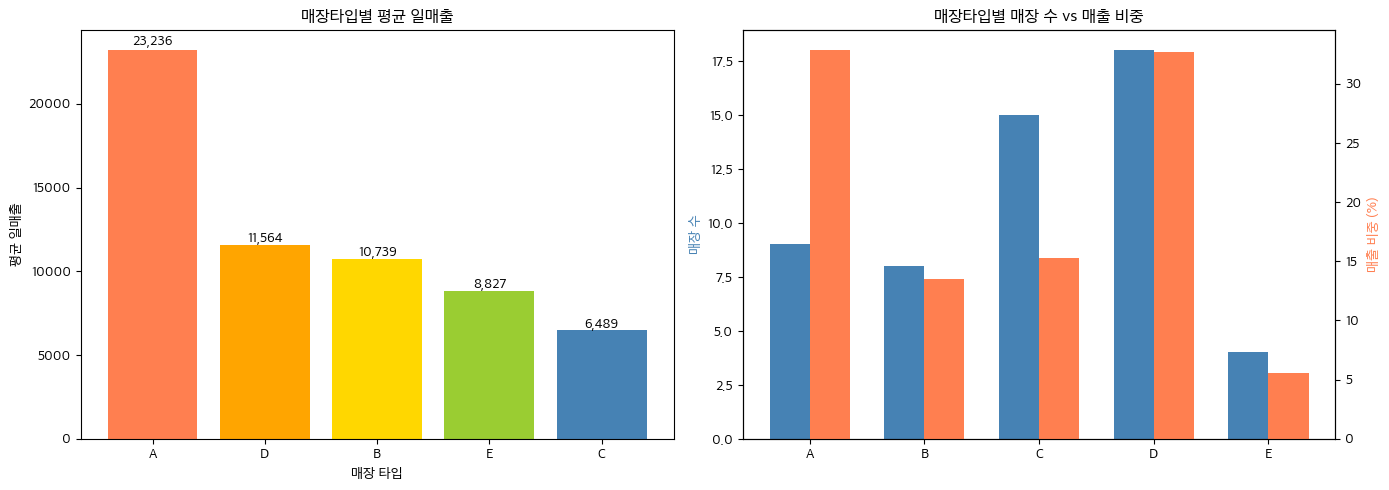

In [111]:
# 매장타입별 매출
type_sales = store_sales.groupby('type')['sales'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. 매장타입별 평균 일매출
colors_type = ['coral', 'orange', 'gold', 'yellowgreen', 'steelblue']
axes[0].bar(type_sales.index, type_sales.values, color=colors_type)
axes[0].set_title('매장타입별 평균 일매출', fontsize=12, fontweight='bold')
axes[0].set_xlabel('매장 타입')
axes[0].set_ylabel('평균 일매출')

for i, v in enumerate(type_sales.values):
    axes[0].text(i, v + v*0.01, f'{v:,.0f}', ha='center', fontsize=10)

# 2. 매장타입별 매장 수 & 매출 비중
type_count = stores['type'].value_counts().sort_index()
type_total = store_sales.groupby('type')['sales'].sum().sort_index()
total_sales_all = type_total.sum()

x = range(len(type_count))
width = 0.35

ax1 = axes[1]
ax2 = ax1.twinx()

bars1 = ax1.bar([i - width/2 for i in x], type_count.values, width, label='매장 수', color='steelblue')
bars2 = ax2.bar([i + width/2 for i in x], (type_total / total_sales_all * 100).values, width, label='매출 비중 (%)', color='coral')

ax1.set_xticks(x)
ax1.set_xticklabels(type_count.index)
ax1.set_ylabel('매장 수', color='steelblue')
ax2.set_ylabel('매출 비중 (%)', color='coral')
ax1.set_title('매장타입별 매장 수 vs 매출 비중', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### 1.4.4 도시별 매출 분석

도시별 매출 분석은 **지역 소비 패턴의 차이**를 파악합니다. 수도 Quito와 항구 도시 Guayaquil의 소비 패턴이 다를 수 있으며, 도시별 매출 규모와 성장률을 비교하여 지역별 마케팅 전략을 수립합니다.


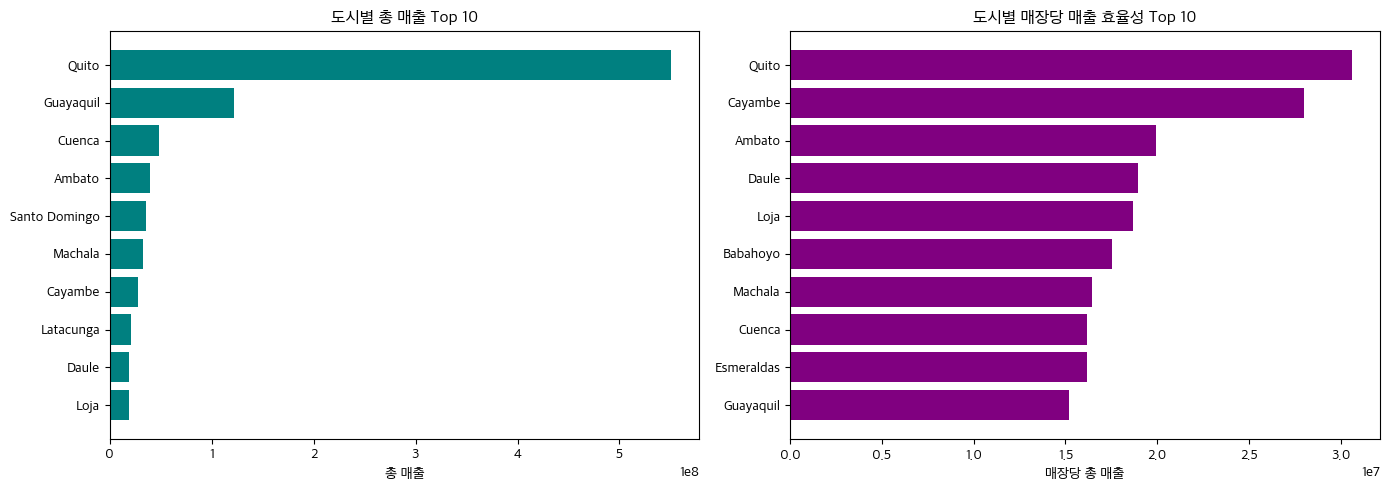

In [112]:
# 도시별 매출 분석
city_sales = store_sales.groupby('city')['sales'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. 도시별 총 매출 Top 10
top10_cities = city_sales.head(10)
axes[0].barh(range(len(top10_cities)), top10_cities.values, color='teal')
axes[0].set_yticks(range(len(top10_cities)))
axes[0].set_yticklabels(top10_cities.index)
axes[0].set_title('도시별 총 매출 Top 10', fontsize=12, fontweight='bold')
axes[0].set_xlabel('총 매출')
axes[0].invert_yaxis()

# 2. 도시별 매장 수 대비 매출 효율성
city_count = stores.groupby('city').size()
city_efficiency = (city_sales / city_count).sort_values(ascending=False).head(10)

axes[1].barh(range(len(city_efficiency)), city_efficiency.values, color='purple')
axes[1].set_yticks(range(len(city_efficiency)))
axes[1].set_yticklabels(city_efficiency.index)
axes[1].set_title('도시별 매장당 매출 효율성 Top 10', fontsize=12, fontweight='bold')
axes[1].set_xlabel('매장당 총 매출')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [ ]:
# 1.4.3~4 분석 결과 CSV 저장
type_summary = store_sales.groupby('type')['sales'].agg(['mean', 'sum', 'count']).reset_index()
type_summary.columns = ['type', 'avg_daily_sales', 'total_sales', 'records']
type_summary.to_csv(f'{EXPORT_PATH}type_sales.csv', index=False)

city_summary = store_sales.groupby('city')['sales'].agg(['mean', 'sum']).reset_index()
city_summary.columns = ['city', 'avg_daily_sales', 'total_sales']
city_summary.to_csv(f'{EXPORT_PATH}city_sales.csv', index=False)

print(f"1.4.3~4 CSV 저장 완료: {EXPORT_PATH}")

## 1.4.3~1.4.4 매장 타입 및 도시별 분석

### 분석 요약 표 (타입·도시 세분화)

| 분석 축 | 핵심으로 보는 지표 | 비즈니스 시사점 |
|--------|-------------------|----------------|
| **매장 타입 (A~E)** | 총매출, 매장 수, **매장당 평균 일매출**, 매출 비중(%) | 총매출만 보면 매장 수 효과에 가려질 수 있음 → **매장당 효율**로 출점·CAPEX·운영 우선순위 판단 |
| **도시** | 총 매출 규모(Top 10), **매장당 매출 효율**(Top 10) | **총매출 상위** 도시와 **효율 상위** 도시가 겹치지 않을 수 있음 → 집중도·성장·효율을 구분해 지역 전략 수립 |

### 1. 매장 타입별 효율성 (1.4.3)
- 타입(A~E)은 **규모·형태**에 따른 분류로, **총매출**과 **매장당 평균 매출(효율)**을 함께 봐야 함
- 예: 특정 타입이 총매출은 크지만 **매장 수가 많아서**일 수 있고, 다른 타입은 **매장당 효율**이 더 높을 수 있음
- 효율성 관점은 **신규 출점·리모델링·SKU·인력** 등 운영·투자 판단에 직결됨

### 2. 도시별 매출 (1.4.4)
- **지역 소비 패턴 차이**를 파악하는 축 — 예: 수도 **Quito**, 항구 **Guayaquil** 등 도시별 특성이 다를 수 있음
- **도시별 총 매출**과 **매장 수 대비 매출(매장당)**을 동시에 보면 **규모**와 **효율**을 분리해 해석 가능
- 도시별 매출이 **특정 도시에 집중**되는 경향이 있으면 리스크·기회 모두 **지역별 전략**으로 다룰 수 있음

### 3. 핵심 정리 (한눈에)
- **타입**: 총매출 + 매장당 효율을 같이 봐야 운영·투자 판단에 유용함
- **도시**: 총매출 쏠림과 효율 상위 도시를 구분해 **지역별 마케팅·물류·프로모션**에 활용
- **타입×도시** 조합으로 강점·약점 매장 그룹을 나누면 **차별화 전략**(목표·KPI·실험 단위)을 세우기 쉬움

### 4. 전략적 시사
1. 타입별로 **총매출 순위만**으로 자원을 배분하기보다 **매장당 매출·이익 기여**를 함께 검토
2. 도시는 **총매출 Top**과 **매장당 효율 Top**을 나란히 보고, 집중 투자 vs 효율 개선 과제를 구분
3. **클러스터(1.4.1~1.4.2)**·**거래/객단가(1.5)**와 엮어 같은 타입·도시 안에서도 세그먼트를 좁혀 액션 설계

In [ ]:
md_parts.append("""
## 1.4.3~1.4.4 매장 타입 및 도시별 분석

### 분석 요약 표 (타입·도시 세분화)

| 분석 축 | 핵심으로 보는 지표 | 비즈니스 시사점 |
|--------|-------------------|----------------|
| **매장 타입 (A~E)** | 총매출, 매장 수, **매장당 평균 일매출**, 매출 비중(%) | 총매출만 보면 매장 수 효과에 가려질 수 있음 → **매장당 효율**로 출점·CAPEX·운영 우선순위 판단 |
| **도시** | 총 매출 규모(Top 10), **매장당 매출 효율**(Top 10) | **총매출 상위** 도시와 **효율 상위** 도시가 겹치지 않을 수 있음 → 집중도·성장·효율을 구분해 지역 전략 수립 |

### 1. 매장 타입별 효율성 (1.4.3)
- 타입(A~E)은 **규모·형태**에 따른 분류로, **총매출**과 **매장당 평균 매출(효율)**을 함께 봐야 함
- 예: 특정 타입이 총매출은 크지만 **매장 수가 많아서**일 수 있고, 다른 타입은 **매장당 효율**이 더 높을 수 있음
- 효율성 관점은 **신규 출점·리모델링·SKU·인력** 등 운영·투자 판단에 직결됨

### 2. 도시별 매출 (1.4.4)
- **지역 소비 패턴 차이**를 파악하는 축 — 예: 수도 **Quito**, 항구 **Guayaquil** 등 도시별 특성이 다를 수 있음
- **도시별 총 매출**과 **매장 수 대비 매출(매장당)**을 동시에 보면 **규모**와 **효율**을 분리해 해석 가능
- 도시별 매출이 **특정 도시에 집중**되는 경향이 있으면 리스크·기회 모두 **지역별 전략**으로 다룰 수 있음

### 3. 핵심 정리 (한눈에)
- **타입**: 총매출 + 매장당 효율을 같이 봐야 운영·투자 판단에 유용함
- **도시**: 총매출 쏠림과 효율 상위 도시를 구분해 **지역별 마케팅·물류·프로모션**에 활용
- **타입×도시** 조합으로 강점·약점 매장 그룹을 나누면 **차별화 전략**(목표·KPI·실험 단위)을 세우기 쉬움

### 4. 전략적 시사
1. 타입별로 **총매출 순위만**으로 자원을 배분하기보다 **매장당 매출·이익 기여**를 함께 검토
2. 도시는 **총매출 Top**과 **매장당 효율 Top**을 나란히 보고, 집중 투자 vs 효율 개선 과제를 구분
3. **클러스터(1.4.1~1.4.2)**·**거래/객단가(1.5)**와 엮어 같은 타입·도시 안에서도 세그먼트를 좁혀 액션 설계
""")
print(f"md_parts 누적 완료 ({len(md_parts)}개)")

## 1.5 거래 및 객단가 분석

> transactions.csv 데이터를 활용하여 **객단가(Basket Size)** 기반 분석을 수행합니다.
>
> **핵심 KPI**: 매출 = 거래건수 × 객단가
>
> 이 분해를 통해 매출 변화의 원인을 구조적으로 파악할 수 있습니다.

### 1.5.1 객단가 기본 분석

**객단가(건당매출)**는 1건의 거래에서 발생하는 평균 매출입니다:

```
객단가 = 총매출 / 거래건수
```

객단가는 **고객이 얼마나 많이 사는지**를 나타내는 핵심 KPI입니다. 매출 = 거래건수 × 객단가이므로, 매출 변화의 원인이 "고객이 덜 왔는지(거래건수 감소)" vs "고객이 덜 샀는지(객단가 하락)"를 구분할 수 있습니다.


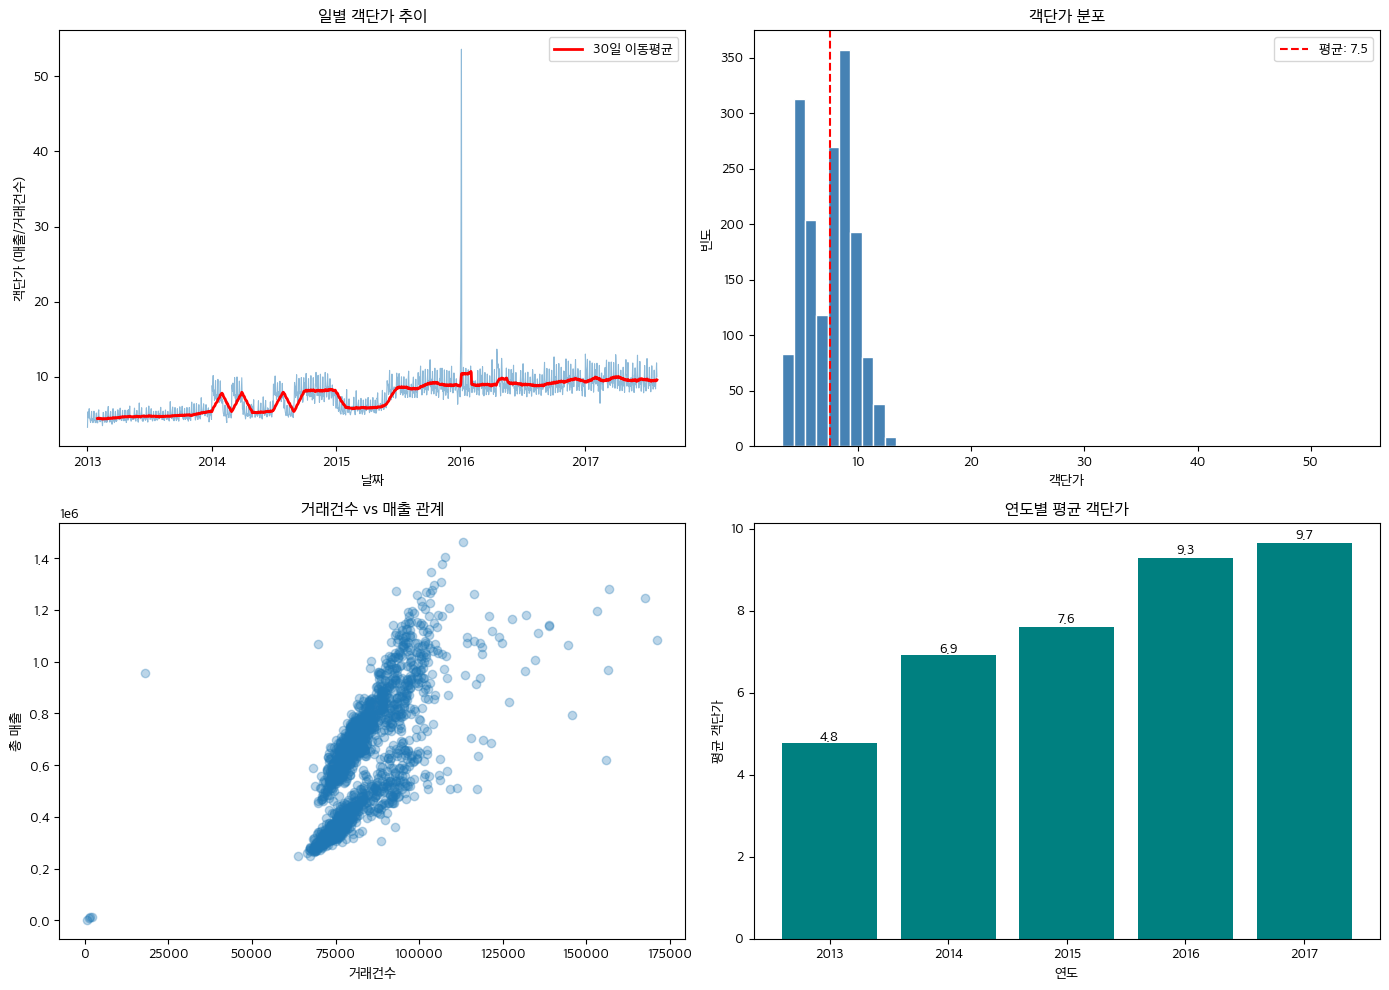

In [113]:
# 일별 거래건수-매출 병합
daily_trans = transactions.groupby('date')['transactions'].sum().reset_index()
daily_merged = daily_sales.merge(daily_trans, on='date', how='inner')

# 객단가(Basket Size) 계산
daily_merged['basket_size'] = daily_merged['total_sales'] / daily_merged['transactions']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. 객단가 추이
axes[0, 0].plot(daily_merged['date'], daily_merged['basket_size'], alpha=0.5, linewidth=0.8)
axes[0, 0].set_title('일별 객단가 추이', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('날짜')
axes[0, 0].set_ylabel('객단가 (매출/거래건수)')

# 30일 이동평균 추가
daily_merged['basket_ma30'] = daily_merged['basket_size'].rolling(30).mean()
axes[0, 0].plot(daily_merged['date'], daily_merged['basket_ma30'], color='red', linewidth=2, label='30일 이동평균')
axes[0, 0].legend()

# 2. 객단가 분포
axes[0, 1].hist(daily_merged['basket_size'], bins=50, color='steelblue', edgecolor='white')
axes[0, 1].axvline(daily_merged['basket_size'].mean(), color='red', linestyle='--', 
                   label=f'평균: {daily_merged["basket_size"].mean():.1f}')
axes[0, 1].set_title('객단가 분포', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('객단가')
axes[0, 1].set_ylabel('빈도')
axes[0, 1].legend()

# 3. 거래건수 vs 매출 관계
axes[1, 0].scatter(daily_merged['transactions'], daily_merged['total_sales'], alpha=0.3)
axes[1, 0].set_title('거래건수 vs 매출 관계', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('거래건수')
axes[1, 0].set_ylabel('총 매출')

# 4. 연도별 평균 객단가
yearly_basket = daily_merged.groupby('year')['basket_size'].mean()
axes[1, 1].bar(yearly_basket.index, yearly_basket.values, color='teal')
axes[1, 1].set_title('연도별 평균 객단가', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('연도')
axes[1, 1].set_ylabel('평균 객단가')

for i, v in enumerate(yearly_basket.values):
    axes[1, 1].text(yearly_basket.index[i], v + v*0.01, f'{v:.1f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# [객단가 기본 통계]

In [114]:
# ============================================================================
# 객단가 이상치 확인 (튀는 날짜 데이터 직접 확인용)
# ============================================================================

# 객단가 상위 10일 확인
outlier_dates = daily_merged.nlargest(10, 'basket_size')[['date', 'total_sales', 'transactions', 'basket_size']]
outlier_dates['date_str'] = outlier_dates['date'].dt.strftime('%Y-%m-%d (%a)')

# 객단가 상위 10일 출력
display(outlier_dates)

# 최대 이상치 날짜의 상세 데이터
max_outlier_date = outlier_dates.iloc[0]['date']

# 해당 날짜의 매장별 데이터
outlier_day_data = train[train['date'] == max_outlier_date]
store_summary = outlier_day_data.groupby('store_nbr')['sales'].sum().sort_values(ascending=False)

# 해당 날짜의 거래건수
outlier_trans = transactions[transactions['date'] == max_outlier_date]

# 전후 날짜 비교
nearby_dates = daily_merged[
    (daily_merged['date'] >= max_outlier_date - pd.Timedelta(days=3)) & 
    (daily_merged['date'] <= max_outlier_date + pd.Timedelta(days=3))
][['date', 'total_sales', 'transactions', 'basket_size']]
nearby_dates['date_str'] = nearby_dates['date'].dt.strftime('%Y-%m-%d')

# 전후 날짜 비교 결과 출력
display(nearby_dates)

,date,total_sales,transactions,basket_size,date_str
1093,2016-01-04,9.559569e+05,17829,53.618087,2016-01-04 (Mon)
1092,2016-01-02,1.066677e+06,69628,15.319662,2016-01-02 (Sat)
1197,2016-04-17,1.271834e+06,93018,13.672985,2016-04-17 (Sun)
1456,2017-01-02,1.402306e+06,107718,13.018311,2017-01-02 (Mon)
1198,2016-04-18,1.345921e+06,103559,12.996655,2016-04-18 (Mon)
1545,2017-04-01,1.463084e+06,113083,12.938142,2017-04-01 (Sat)
1609,2017-06-04,1.376512e+06,106972,12.867961,2017-06-04 (Sun)
1365,2016-10-02,1.256480e+06,99386,12.642426,2016-10-02 (Sun)
1211,2016-05-01,1.270121e+06,102012,12.450704,2016-05-01 (Sun)
1637,2017-07-02,1.296379e+06,104392,12.418377,2017-07-02 (Sun)


,date,total_sales,transactions,basket_size,date_str
1092,2016-01-02,1.066677e+06,69628,15.319662,2016-01-02
1093,2016-01-04,9.559569e+05,17829,53.618087,2016-01-04
1094,2016-01-05,8.353204e+05,89018,9.383725,2016-01-05
1095,2016-01-06,8.216857e+05,88846,9.248426,2016-01-06
1096,2016-01-07,6.535044e+05,80412,8.126951,2016-01-07


### 1.5.2 성장 분해 분석

> **성장 분해 공식**: 매출 성장률 ≈ 거래건수 성장률 + 객단가 성장률

,year,sales_growth,trans_growth,basket_growth
1,2014,49.177978,3.091183,44.704886
2,2015,14.992704,4.350465,10.198555
3,2016,19.317184,-0.830448,20.316349


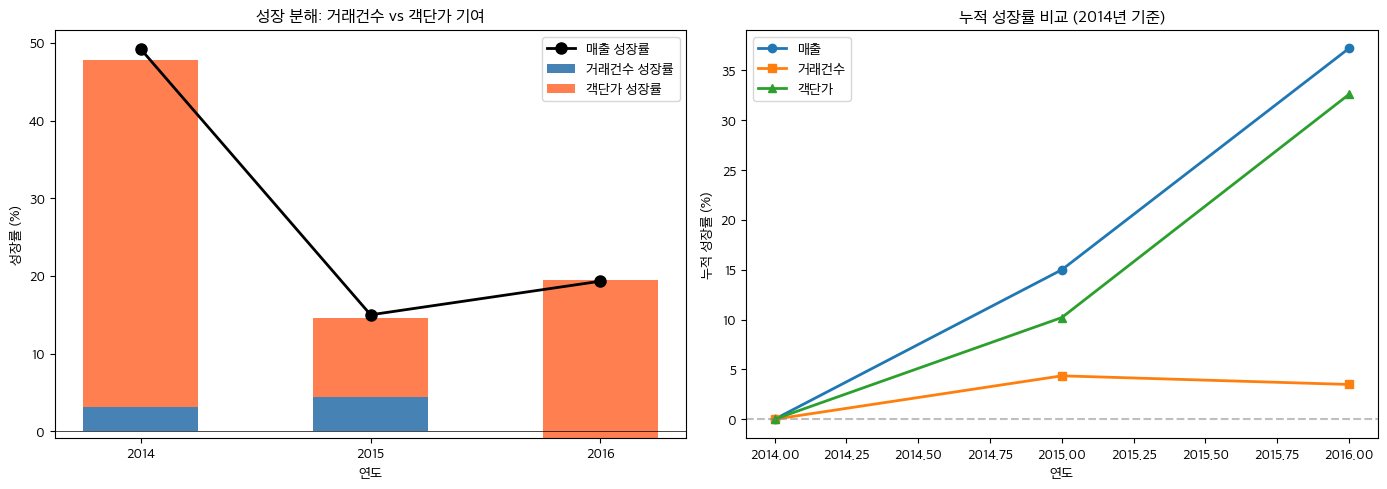

In [115]:
# 연도별 집계 (2017년 제외 - 데이터 불완전)
yearly_growth = daily_merged[daily_merged['year'] < 2017].groupby('year').agg({
    'total_sales': 'sum',
    'transactions': 'sum'
}).reset_index()
yearly_growth['basket_size'] = yearly_growth['total_sales'] / yearly_growth['transactions']

# 성장률 계산
yearly_growth['sales_growth'] = yearly_growth['total_sales'].pct_change() * 100
yearly_growth['trans_growth'] = yearly_growth['transactions'].pct_change() * 100
yearly_growth['basket_growth'] = yearly_growth['basket_size'].pct_change() * 100

# 연도별 성장률 분해:
display(yearly_growth[['year', 'sales_growth', 'trans_growth', 'basket_growth']].dropna())

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. 성장률 분해 (Stacked Bar)
growth_data = yearly_growth.dropna()
x = growth_data['year'].astype(str)
width = 0.5

ax = axes[0]
ax.bar(x, growth_data['trans_growth'], width, label='거래건수 성장률', color='steelblue')
ax.bar(x, growth_data['basket_growth'], width, bottom=growth_data['trans_growth'], 
       label='객단가 성장률', color='coral')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.plot(x, growth_data['sales_growth'], 'ko-', linewidth=2, markersize=8, label='매출 성장률')
ax.set_title('성장 분해: 거래건수 vs 객단가 기여', fontsize=12, fontweight='bold')
ax.set_xlabel('연도')
ax.set_ylabel('성장률 (%)')
ax.legend()

# 2. 누적 성장 비교
years_growth = yearly_growth[yearly_growth['year'] >= 2014].copy()
years_growth['sales_cum'] = (years_growth['total_sales'] / years_growth['total_sales'].iloc[0] - 1) * 100
years_growth['trans_cum'] = (years_growth['transactions'] / years_growth['transactions'].iloc[0] - 1) * 100
years_growth['basket_cum'] = (years_growth['basket_size'] / years_growth['basket_size'].iloc[0] - 1) * 100

axes[1].plot(years_growth['year'], years_growth['sales_cum'], 'o-', label='매출', linewidth=2)
axes[1].plot(years_growth['year'], years_growth['trans_cum'], 's-', label='거래건수', linewidth=2)
axes[1].plot(years_growth['year'], years_growth['basket_cum'], '^-', label='객단가', linewidth=2)
axes[1].set_title('누적 성장률 비교 (2014년 기준)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('연도')
axes[1].set_ylabel('누적 성장률 (%)')
axes[1].legend()
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
# 1.5.1~2 분석 결과 CSV 저장
growth_decomp_df = yearly_growth[['year', 'total_sales', 'transactions', 'basket_size',
                                   'sales_growth', 'trans_growth', 'basket_growth']].copy()
growth_decomp_df.to_csv(f'{EXPORT_PATH}growth_decomposition.csv', index=False)

print(f"1.5.1~2 CSV 저장 완료: {EXPORT_PATH}")

## 1.5.1~1.5.2 객단가 및 성장 분해

### 분석 요약 표 (성장 분해)

| 분석 항목 | 핵심 프레임 | 비즈니스 시사점 |
|----------|------------|----------------|
| **성장 분해** | 매출 = 거래건수 × 객단가(건당매출) | 연도별 성장을 **거래 확대**와 **객단가(건당매출) 상승**으로 나누어 해석 |
| **구간별 기여** | 분해 결과(연도·누적 성장률 비교) | 분석 구간에서 **건당매출(객단가) 쪽 기여가 상대적으로 크고**, 거래건수 기여는 제한적 → **거래건수 확대 여력**에 주목 가능 |
| **데이터 주의** | 2017년 관측 | **불완전할 수 있음** → 연도별 분해·해석 시 **제외하거나 신중히** 다룸 |

### 1. 분해 프레임 (1.5.1)
- **매출 = 거래건수 × 객단가(건당매출)** 로 두 요인을 분리하면, 성장이 **트래픽**에서 오는지 **바구니 크기**에서 오는지 구조적으로 볼 수 있음
- YoY·누적 성장률 그래프로 **어느 축이 끌어올리는지**를 한눈에 비교 가능

### 2. 해석 방향 (1.5.2)
- 구간에서 **객단가(건당매출) 기여가 두드러지고** 거래건수 기여가 상대적으로 작다면, **유입·전환·재방문** 등 거래건수 레버에 **추가 실험·투자** 여지가 있음
- 반대로 거래가 이미 높은 수준이면 **업셀·믹스·프로모션 설계**가 객단가 축과 맞물려 있는지 점검

### 3. 핵심 정리 (한눈에)
- 성장 원인을 **거래 vs 객단가**로 나누어 말할 수 있어야 전략 대화가 정렬됨
- **2017년**은 연말·수집 기간 등으로 **왜곡**될 수 있으니 민감도 분석(포함/제외)을 권장

### 4. 전략적 시사
1. **KPI를 이중으로** 잡기: 총매출뿐 아니라 **거래건수·객단가** 추이를 함께 모니터링
2. 객단가 주도 성장이면 **거래건수 목표·캠페인(유입·빈도)**을 병행 검토
3. **2017년 제외·주석**을 표준으로 두고 이후 연도 패턴을 우선 의사결정에 사용

In [ ]:
md_parts.append("""
## 1.5.1~1.5.2 객단가 및 성장 분해

### 분석 요약 표 (성장 분해)

| 분석 항목 | 핵심 프레임 | 비즈니스 시사점 |
|----------|------------|----------------|
| **성장 분해** | 매출 = 거래건수 × 객단가(건당매출) | 연도별 성장을 **거래 확대**와 **객단가(건당매출) 상승**으로 나누어 해석 |
| **구간별 기여** | 분해 결과(연도·누적 성장률 비교) | 분석 구간에서 **건당매출(객단가) 쪽 기여가 상대적으로 크고**, 거래건수 기여는 제한적 → **거래건수 확대 여력**에 주목 가능 |
| **데이터 주의** | 2017년 관측 | **불완전할 수 있음** → 연도별 분해·해석 시 **제외하거나 신중히** 다룸 |

### 1. 분해 프레임 (1.5.1)
- **매출 = 거래건수 × 객단가(건당매출)** 로 두 요인을 분리하면, 성장이 **트래픽**에서 오는지 **바구니 크기**에서 오는지 구조적으로 볼 수 있음
- YoY·누적 성장률 그래프로 **어느 축이 끌어올리는지**를 한눈에 비교 가능

### 2. 해석 방향 (1.5.2)
- 구간에서 **객단가(건당매출) 기여가 두드러지고** 거래건수 기여가 상대적으로 작다면, **유입·전환·재방문** 등 거래건수 레버에 **추가 실험·투자** 여지가 있음
- 반대로 거래가 이미 높은 수준이면 **업셀·믹스·프로모션 설계**가 객단가 축과 맞물려 있는지 점검

### 3. 핵심 정리 (한눈에)
- 성장 원인을 **거래 vs 객단가**로 나누어 말할 수 있어야 전략 대화가 정렬됨
- **2017년**은 연말·수집 기간 등으로 **왜곡**될 수 있으니 민감도 분석(포함/제외)을 권장

### 4. 전략적 시사
1. **KPI를 이중으로** 잡기: 총매출뿐 아니라 **거래건수·객단가** 추이를 함께 모니터링
2. 객단가 주도 성장이면 **거래건수 목표·캠페인(유입·빈도)**을 병행 검토
3. **2017년 제외·주석**을 표준으로 두고 이후 연도 패턴을 우선 의사결정에 사용
""")
print(f"md_parts 누적 완료 ({len(md_parts)}개)")

### 1.5.3 객단가 효율성 분석 (매장별)

**4분면 분석**은 매장을 거래건수(X축)와 객단가(Y축) 기준으로 4개 그룹으로 분류한다:

| 사분면 | 거래건수 | 객단가 | 전략 |
|--------|---------|--------|------|
| 우상 | 높음 | 높음 | 우수 매장 — 벤치마크 |
| 좌상 | 낮음 | 높음 | 고객 유입 강화 필요 |
| 좌하 | 낮음 | 낮음 | 구조적 문제 진단 |
| 우하 | 높음 | 낮음 | 업셀링/크로스셀링 기회 |

각 매장이 어느 사분면에 위치하는지에 따라 차별화된 전략을 적용합니다.


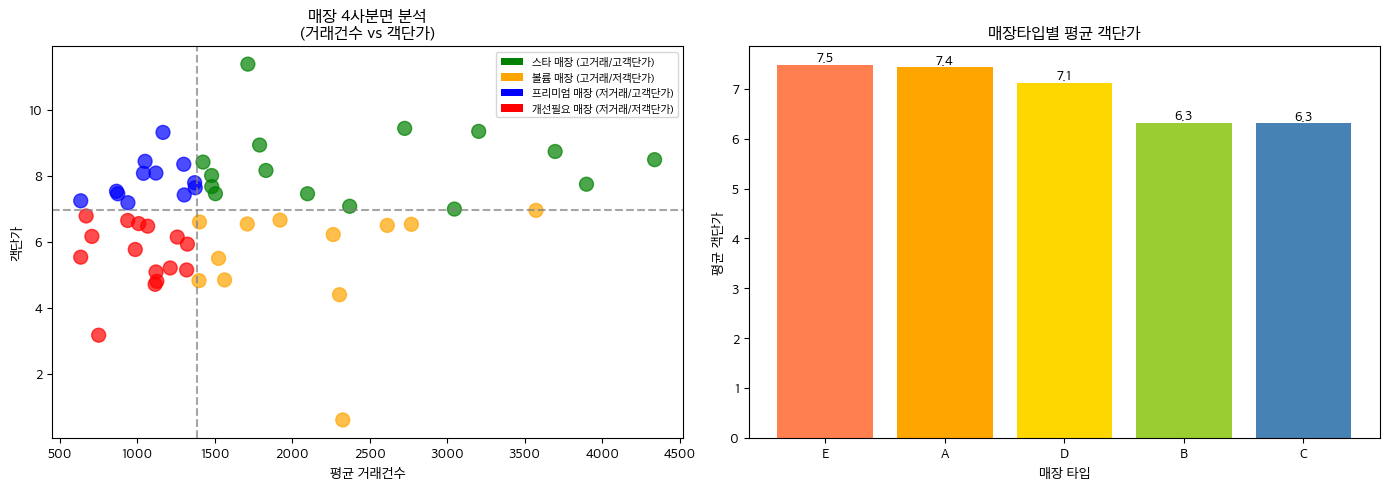

In [116]:
# 매장별 객단가 효율성 분석
trans_with_store = transactions.merge(stores, on='store_nbr', how='left')
store_trans = trans_with_store.groupby('store_nbr')['transactions'].mean().reset_index()
store_trans.columns = ['store_nbr', 'avg_transactions']

store_daily_sales = store_sales.groupby('store_nbr')['sales'].mean().reset_index()
store_daily_sales.columns = ['store_nbr', 'avg_sales']

store_basket = store_trans.merge(store_daily_sales, on='store_nbr')
store_basket = store_basket.merge(stores, on='store_nbr')
store_basket['basket_size'] = store_basket['avg_sales'] / store_basket['avg_transactions']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. 4사분면 분석: 거래건수 vs 객단가
median_trans = store_basket['avg_transactions'].median()
median_basket = store_basket['basket_size'].median()

colors_quad = []
for _, row in store_basket.iterrows():
    if row['avg_transactions'] >= median_trans and row['basket_size'] >= median_basket:
        colors_quad.append('green')  # 고거래, 고객단가 (우상)
    elif row['avg_transactions'] >= median_trans:
        colors_quad.append('orange')  # 고거래, 저객단가 (우하)
    elif row['basket_size'] >= median_basket:
        colors_quad.append('blue')  # 저거래, 고객단가 (좌상)
    else:
        colors_quad.append('red')  # 저거래, 저객단가 (좌하)

axes[0].scatter(store_basket['avg_transactions'], store_basket['basket_size'], 
                c=colors_quad, s=100, alpha=0.7)
axes[0].axvline(x=median_trans, color='gray', linestyle='--', alpha=0.7)
axes[0].axhline(y=median_basket, color='gray', linestyle='--', alpha=0.7)
axes[0].set_xlabel('평균 거래건수')
axes[0].set_ylabel('객단가')
axes[0].set_title('매장 4사분면 분석\n(거래건수 vs 객단가)', fontsize=12, fontweight='bold')

# 범례 추가
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='green', label='스타 매장 (고거래/고객단가)'),
    Patch(facecolor='orange', label='볼륨 매장 (고거래/저객단가)'),
    Patch(facecolor='blue', label='프리미엄 매장 (저거래/고객단가)'),
    Patch(facecolor='red', label='개선필요 매장 (저거래/저객단가)')
]
axes[0].legend(handles=legend_elements, loc='upper right', fontsize=8)

# 2. 매장타입별 객단가
type_basket = store_basket.groupby('type')['basket_size'].mean().sort_values(ascending=False)
axes[1].bar(type_basket.index, type_basket.values, color=['coral', 'orange', 'gold', 'yellowgreen', 'steelblue'])
axes[1].set_title('매장타입별 평균 객단가', fontsize=12, fontweight='bold')
axes[1].set_xlabel('매장 타입')
axes[1].set_ylabel('평균 객단가')

for i, v in enumerate(type_basket.values):
    axes[1].text(i, v + v*0.01, f'{v:.1f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# 사분면별 매장 수
store_basket['quadrant'] = colors_quad
quadrant_counts = store_basket['quadrant'].value_counts()

### 1.5.4 건당 매출 변화 원인 분석

매출 성장을 **거래건수 증가**와 **건당 매출 증가**로 분해하고, 건당 매출 변화의 원인을 분석합니다.

**핵심 질문:**
1. 매출 성장은 거래건수 증가 때문인가, 건당 매출 증가 때문인가?
2. 건당 매출이 변했다면, 어떤 카테고리가 영향을 미쳤는가?

>  **분석 프레임워크 (성장 분해)**: 
> ```
> 총매출 = 거래건수 × 건당 매출
> 
> 따라서 매출 성장률 ≈ 거래건수 성장률 + 건당 매출 성장률
> ```

>  **데이터 한계:**
> - 2017년은 7월까지만 데이터  연간 비교에서 제외 (2016년까지 분석)
> - 제품 가격(Price)과 판매 수량(Quantity) 데이터 없음

In [117]:
# 연도별 총매출, 거래건수, 건당매출 계산
train['year'] = train['date'].dt.year
transactions['year'] = transactions['date'].dt.year

# 연도별 총매출
yearly_sales = train.groupby('year')['sales'].sum().reset_index()
yearly_sales.columns = ['year', 'total_sales']

# 연도별 총 거래건수
yearly_trans = transactions.groupby('year')['transactions'].sum().reset_index()
yearly_trans.columns = ['year', 'total_transactions']

# 병합 및 건당매출 계산
growth_decomp = yearly_sales.merge(yearly_trans, on='year')
growth_decomp['basket_size'] = growth_decomp['total_sales'] / growth_decomp['total_transactions']

# 2013년 대비 성장률 계산
base = growth_decomp[growth_decomp['year'] == 2013].iloc[0]
growth_decomp['sales_growth'] = (growth_decomp['total_sales'] / base['total_sales'] - 1) * 100
growth_decomp['trans_growth'] = (growth_decomp['total_transactions'] / base['total_transactions'] - 1) * 100
growth_decomp['basket_growth'] = (growth_decomp['basket_size'] / base['basket_size'] - 1) * 100

growth_decomp

,year,total_sales,total_transactions,basket_size,sales_growth,trans_growth,basket_growth
0,2013,1.404190e+08,29107173,4.824207,0.000000,0.000000,0.000000
1,2014,2.094742e+08,30006929,6.980863,49.177978,3.091183,44.704886
2,2015,2.408801e+08,31312370,7.692810,71.543792,7.576129,59.462692
3,2016,2.886545e+08,31052337,9.295742,105.566550,6.682765,92.689560
4,2017,1.817837e+08,18664444,9.739575,29.458070,-35.876823,101.889670


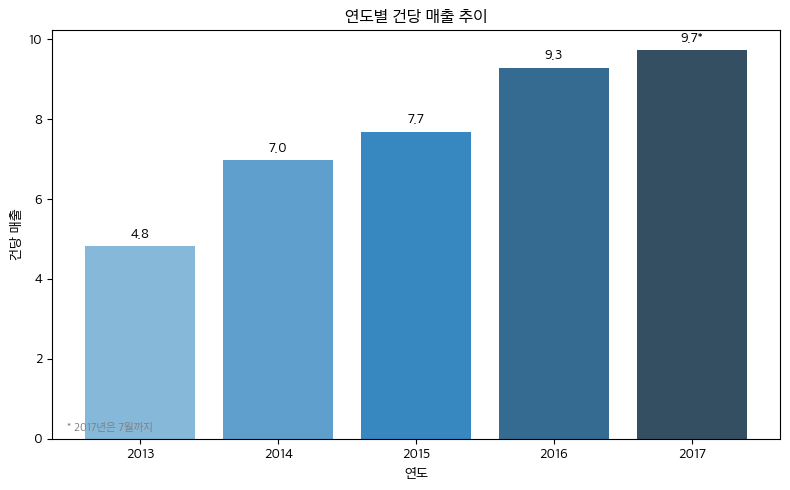

In [118]:
# 연도별 건당 매출 추이 (비율이므로 2017 포함)
fig, ax = plt.subplots(figsize=(8, 5))

colors = sns.color_palette('Blues_d', n_colors=len(growth_decomp))
ax.bar(growth_decomp['year'], growth_decomp['basket_size'], color=colors)
ax.set_title('연도별 건당 매출 추이')
ax.set_xlabel('연도')
ax.set_ylabel('건당 매출')

for _, row in growth_decomp.iterrows():
    label = f"{row['basket_size']:.1f}"
    if row['year'] == 2017:
        label += "*"
    ax.text(row['year'], row['basket_size'] + 0.2, label, ha='center')

ax.annotate('* 2017년은 7월까지', xy=(0.02, 0.02), xycoords='axes fraction', fontsize=8, color='gray')
plt.tight_layout()
plt.show()

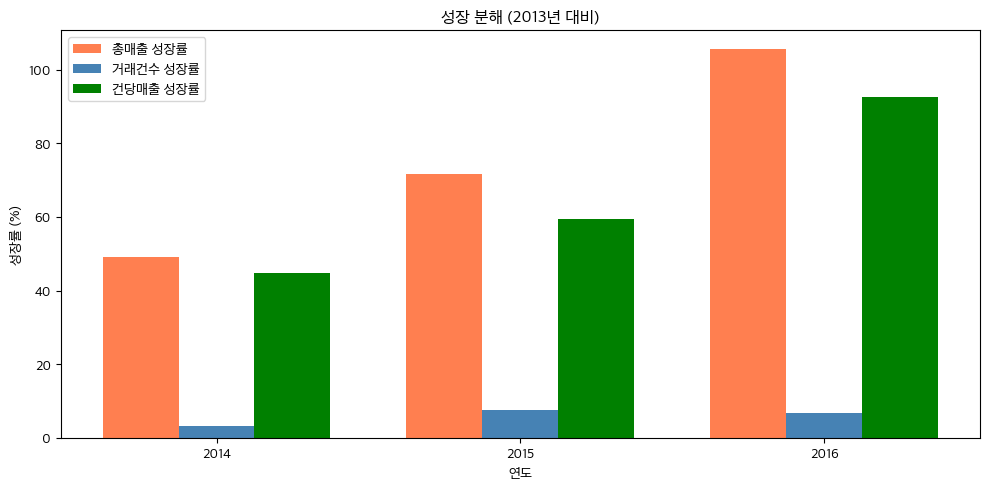

In [119]:
# 성장 분해 (누적 기반이므로 2016까지만 비교)
growth_2016 = growth_decomp[growth_decomp['year'] <= 2016].copy()
chart_data = growth_2016[growth_2016['year'] > 2013]

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(chart_data))
width = 0.25

ax.bar(x - width, chart_data['sales_growth'], width, label='총매출 성장률', color='coral')
ax.bar(x, chart_data['trans_growth'], width, label='거래건수 성장률', color='steelblue')
ax.bar(x + width, chart_data['basket_growth'], width, label='건당매출 성장률', color='green')

ax.set_title('성장 분해 (2013년 대비)')
ax.set_xlabel('연도')
ax.set_ylabel('성장률 (%)')
ax.set_xticks(x)
ax.set_xticklabels(chart_data['year'].astype(int))
ax.legend()
ax.axhline(y=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()


In [120]:
# 연도별 카테고리 매출 비중 및 순위 계산
yearly_family = train.groupby(['year', 'family'])['sales'].sum().reset_index()
yearly_total = train.groupby('year')['sales'].sum().reset_index()
yearly_total.columns = ['year', 'total_sales']

yearly_family = yearly_family.merge(yearly_total, on='year')
yearly_family['share'] = yearly_family['sales'] / yearly_family['total_sales'] * 100

# 연도별 순위 계산
yearly_family['rank'] = yearly_family.groupby('year')['sales'].rank(ascending=False)

# 2013 vs 2016 순위 변화
rank_2013 = yearly_family[yearly_family['year'] == 2013][['family', 'rank', 'share']]
rank_2016 = yearly_family[yearly_family['year'] == 2016][['family', 'rank', 'share']]
rank_change = rank_2013.merge(rank_2016, on='family', suffixes=('_2013', '_2016'))
rank_change['rank_change'] = rank_change['rank_2013'] - rank_change['rank_2016']
rank_change['share_change'] = rank_change['share_2016'] - rank_change['share_2013']

# 상승/하락 TOP 5
rising = rank_change.nlargest(5, 'rank_change')
falling = rank_change.nsmallest(5, 'rank_change')

# 순위 상승 TOP 5:
display(rising[['family', 'rank_2013', 'rank_2016', 'rank_change', 'share_change']])

display(falling[['family', 'rank_2013', 'rank_2016', 'rank_change', 'share_change']])

,family,rank_2013,rank_2016,rank_change,share_change
18,HOME CARE,28.0,11.0,17.0,1.950634
30,PRODUCE,18.0,3.0,15.0,15.277238
15,HOME AND KITCHEN I,28.0,16.0,12.0,0.199557
16,HOME AND KITCHEN II,28.0,17.0,11.0,0.180512
6,CELEBRATION,28.0,20.0,8.0,0.096572


,family,rank_2013,rank_2016,rank_change,share_change
21,LINGERIE,16.0,27.0,-11.0,-0.079233
14,HARDWARE,21.0,30.0,-9.0,-0.004182
17,HOME APPLIANCES,22.0,31.0,-9.0,-0.004699
2,BEAUTY,20.0,28.0,-8.0,0.000726
20,LAWN AND GARDEN,19.0,26.0,-7.0,0.004645


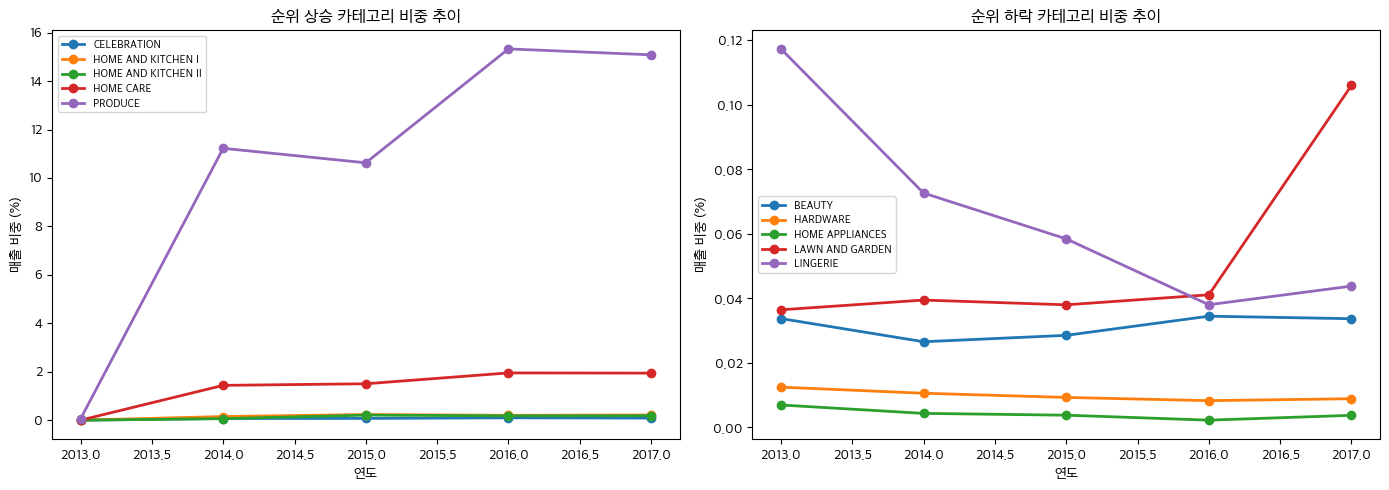

In [121]:
# 순위 변화 카테고리 추이 시각화 (비중이므로 2017 포함)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 상승 카테고리 추이
rising_data = yearly_family[yearly_family['family'].isin(rising['family'])]
rising_pivot = rising_data.pivot(index='year', columns='family', values='share')
rising_pivot.plot(ax=axes[0], marker='o', linewidth=2)
axes[0].set_title('순위 상승 카테고리 비중 추이')
axes[0].set_xlabel('연도')
axes[0].set_ylabel('매출 비중 (%)')
axes[0].legend(fontsize=8)

# 하락 카테고리 추이
falling_data = yearly_family[yearly_family['family'].isin(falling['family'])]
falling_pivot = falling_data.pivot(index='year', columns='family', values='share')
falling_pivot.plot(ax=axes[1], marker='o', linewidth=2)
axes[1].set_title('순위 하락 카테고리 비중 추이')
axes[1].set_xlabel('연도')
axes[1].set_ylabel('매출 비중 (%)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


In [ ]:
# 1.5.3~4 분석 결과 CSV 저장
store_basket_export = store_basket[['store_nbr', 'type', 'city', 'cluster',
                                     'avg_transactions', 'avg_sales', 'basket_size']].copy()
store_basket_export.to_csv(f'{EXPORT_PATH}store_basket_analysis.csv', index=False)

print(f"1.5.3~4 CSV 저장 완료: {EXPORT_PATH}")

## 1.5.3~1.5.4 매장 효율성 및 건당 매출 변화

### 분석 요약 표 (매장·카테고리)

| 분석 항목 | 핵심 방법 | 비즈니스 시사점 |
|----------|----------|----------------|
| **매장 4분면** | 거래건수·객단가(중앙값 기준) | **스타(고거래·고객단가)·볼륨·프리미엄·개선필요** 등 유형별로 **현장 액션**을 나눔 |
| **카테고리 구조** | 연도별 비중·순위 변화 | 건당 매출 변화가 **어떤 카테고리 믹스 변화**와 연결되는지 **구조적 요인**으로 파악 |
| **분해 한계** | 품목 가격·건당 수량 등 미제공 | 건당 매출 변화를 **가격 효과 vs 믹스 효과**로 기계적 분해는 **한계**가 있음 |

### 1. 매장별 효율성 (1.5.3)
- **거래건수(X)·객단가(Y)** 4분면으로 매장을 묶으면, **트래픽은 많은데 객단가가 낮은 매장**(업셀 여지)과 **객단가는 높은데 유입이 부족한 매장**(마케팅·동선)을 구분할 수 있음
- 유형별로 **벤치마크·교육·SKU·프로모션** 적용 단위를 달리할 수 있음

### 2. 건당 매출·카테고리 (1.5.4)
- **연도별 카테고리 비중·순위** 변화는 건당 매출 변동의 **배경 구조**(어떤 품목군이 커지는지)를 설명하는 데 유용함
- 다만 **단가·수량**이 데이터에 없으면 “왜 건당 매출이 올랐는가”를 **가격 vs 믹스**로 끝까지 쪼개기는 어렵고, **가설·추가 데이터**가 필요함

### 3. 핵심 정리 (한눈에)
- 4분면은 **매장 단위 실행 계획**을 세우는 데, 카테고리 추이는 **포트폴리오·조달** 논의와 연결
- **한계를 명시**한 채로 인사이트를 쓰면 과도한 단정을 피할 수 있음

### 4. 전략적 시사
1. 4분면별로 **목표 KPI**(거래·객단가)와 **실험 패키지**를 다르게 설계
2. 카테고리 비중 변화가 큰 연도는 **믹스 변화 가설**을 세우고, 가능하면 **가격·수량** 데이터를 보강해 검증
3. **1.5.1~1.5.2** 성장 분해와 맞춰 “전사는 객단가 vs 매장은 거래”처럼 **레벨이 다른 스토리**가 나오지 않도록 교차 확인

In [ ]:
md_parts.append("""
## 1.5.3~1.5.4 매장 효율성 및 건당 매출 변화

### 분석 요약 표 (매장·카테고리)

| 분석 항목 | 핵심 방법 | 비즈니스 시사점 |
|----------|----------|----------------|
| **매장 4분면** | 거래건수·객단가(중앙값 기준) | **스타(고거래·고객단가)·볼륨·프리미엄·개선필요** 등 유형별로 **현장 액션**을 나눔 |
| **카테고리 구조** | 연도별 비중·순위 변화 | 건당 매출 변화가 **어떤 카테고리 믹스 변화**와 연결되는지 **구조적 요인**으로 파악 |
| **분해 한계** | 품목 가격·건당 수량 등 미제공 | 건당 매출 변화를 **가격 효과 vs 믹스 효과**로 기계적 분해는 **한계**가 있음 |

### 1. 매장별 효율성 (1.5.3)
- **거래건수(X)·객단가(Y)** 4분면으로 매장을 묶으면, **트래픽은 많은데 객단가가 낮은 매장**(업셀 여지)과 **객단가는 높은데 유입이 부족한 매장**(마케팅·동선)을 구분할 수 있음
- 유형별로 **벤치마크·교육·SKU·프로모션** 적용 단위를 달리할 수 있음

### 2. 건당 매출·카테고리 (1.5.4)
- **연도별 카테고리 비중·순위** 변화는 건당 매출 변동의 **배경 구조**(어떤 품목군이 커지는지)를 설명하는 데 유용함
- 다만 **단가·수량**이 데이터에 없으면 “왜 건당 매출이 올랐는가”를 **가격 vs 믹스**로 끝까지 쪼개기는 어렵고, **가설·추가 데이터**가 필요함

### 3. 핵심 정리 (한눈에)
- 4분면은 **매장 단위 실행 계획**을 세우는 데, 카테고리 추이는 **포트폴리오·조달** 논의와 연결
- **한계를 명시**한 채로 인사이트를 쓰면 과도한 단정을 피할 수 있음

### 4. 전략적 시사
1. 4분면별로 **목표 KPI**(거래·객단가)와 **실험 패키지**를 다르게 설계
2. 카테고리 비중 변화가 큰 연도는 **믹스 변화 가설**을 세우고, 가능하면 **가격·수량** 데이터를 보강해 검증
3. **1.5.1~1.5.2** 성장 분해와 맞춰 “전사는 객단가 vs 매장은 거래”처럼 **레벨이 다른 스토리**가 나오지 않도록 교차 확인
""")
print(f"md_parts 누적 완료 ({len(md_parts)}개)")

## 1.6 분석 종합 및 결과 Export

지금까지 수행한 분석 결과를 정리합니다.

### 저장된 CSV 파일 목록

| 섹션 | 파일명 | 내용 |
|------|--------|------|
| 1.2 | daily_sales.csv | 일별 전체 매출 |
| 1.2 | yearly_sales.csv | 연도별 매출 합계 |
| 1.2 | monthly_sales.csv | 월별 매출 추이 |
| 1.2 | yoy_growth.csv | 월별 YoY 성장률 |
| 1.3.1 | promo_effect.csv | 프로모션 유무별 평균 매출 |
| 1.3.1 | category_sales.csv | 카테고리별 매출 |
| 1.3.1 | promo_by_category.csv | 카테고리별 프로모션 리프트 |
| 1.3.2 | weekday_pattern.csv | 요일별 평균 매출 |
| 1.3.4 | holiday_promo_comparison.csv | 휴일×프로모션 교차 비교 |
| 1.3.4 | holiday_pure_effect.csv | 순수 휴일 효과 |
| 1.3.4 | holiday_pattern_d3.csv | 휴일 전후 매출 패턴 |
| 1.4.1 | cluster_sales.csv | 클러스터별 매출 |
| 1.4.2 | cluster_holiday_promo.csv | 클러스터별 휴일×프로모션 효과 |
| 1.4.3 | type_sales.csv | 매장타입별 매출 |
| 1.4.4 | city_sales.csv | 도시별 매출 |
| 1.5.2 | growth_decomposition.csv | 성장 분해 (거래건수 vs 객단가) |
| 1.5.3 | store_basket_analysis.csv | 매장별 객단가 효율성 |

In [ ]:
# 저장된 CSV 파일 확인
import glob

csv_files = sorted(glob.glob(f'{EXPORT_PATH}*.csv'))
print(f"저장된 CSV 파일 ({len(csv_files)}개):")
for f in csv_files:
    print(f"  {f}")

In [ ]:
# 분석 요약·Q&A용 Markdown 파일 생성
md_header = """# Part 1: 매출 데이터 분석 결과 요약

> 분석 대상: 에콰도르 대형 식료품 소매체인 Corporación Favorita
> 생성 방식: 구간별 md_parts 누적 후 자동 병합

---
"""

md_content = md_header + "\n\n---\n\n".join(md_parts)
out_summary = f'{EXPORT_PATH}Part1_분석결과_요약.md'
with open(out_summary, 'w', encoding='utf-8') as f:
    f.write(md_content)
print(f"저장 완료: {out_summary} ({len(md_parts)}개 섹션, {len(md_content):,} 글자)")

qa_lines = ["# Part 1 분석 Q&A 지식베이스\n", "> md_parts 기반 자동 생성\n", "---\n"]
q_num = 1
for part in md_parts:
    lines = [ln for ln in part.strip().split("\n") if ln.strip()]
    if not lines:
        continue
    title = lines[0].replace("## ", "").strip()
    bullets = [ln for ln in lines if ln.strip().startswith("- ")]
    if not bullets:
        continue
    qa_lines.append(f"## Q{q_num}. {title}의 주요 내용은?\n")
    qa_lines.append("**A:**")
    qa_lines.extend(bullets)
    qa_lines.append("\n---\n")
    q_num += 1

qa_content = "\n".join(qa_lines)
out_qa = f'{EXPORT_PATH}Part1_QA_지식베이스.md'
with open(out_qa, 'w', encoding='utf-8') as f:
    f.write(qa_content)
print(f"저장 완료: {out_qa} (Q&A {q_num - 1}개)")